# 01 - Análisis exploratorio (EDA) de la serie horaria de ozono troposférico (O3)

En este segundo notebook, se realizará el análisis exploratorio de la serie horaria de ozono troposférico (O3) registrada por la estación de calidad del aire ubicada en el Eixample para el periodo 2020-2025.

La serie utilizada procede del conjunto de datos generado previamente (a partir de los datos en bruto) en el notebook `notebooks/00_data_preparation_o3.ipynb`.

Las secciones que componen el notebook, tras cargar la serie horaria previamente preparada, son:

1. Calidad de los datos y diferencias entre los bloques cronológicos.
2. Evolución temporal de la serie y comparativa anual.
3. Distribución del ozono troposférico (O3).
4. Estacionalidad diaria, semanal, mensual y mes/hora de la serie temporal.
5. Autocorrelación y estacionariedad.
6. Diagnóstico exploratorio de reglas ingenuas estacionales.
7. Comparación interanual y posible singularidad de 2020.
8. Implicaciones para el modelado y variables candidatas.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.stattools import acf

# Se amplía la cantidad de columnas visibles para inspeccionar mejor las tablas.
pd.set_option("display.max_columns", 100)

# Se evita que pandas corte demasiado pronto las salidas.
pd.set_option("display.max_rows", 100)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    start = Path.cwd() if start is None else start

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("No se ha podido localizar la raíz del proyecto.")


# Se utiliza la función definida para localizar automáticamente el directorio raíz del repositorio.
PROJECT_ROOT = find_project_root()

# Conjunto de datos procesado que se generará a partir del conjunto de datos bruto.
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "o3_hourly.parquet"

# Directorios donde se guardarán las tablas y figuras generadas durante la EDA.
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_GENERATED_DIR = PROJECT_ROOT / "reports" / "figures" / "generated"
FIGURES_FINAL_DIR = PROJECT_ROOT / "reports" / "figures" / "final"

# Se comprueba, adicionalmente, que los directorios de salida existan.
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_GENERATED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset horario base: {PROCESSED_DATA_PATH}")

Raíz del proyecto: c:\trabajo_github
Dataset horario base: c:\trabajo_github\data\processed\o3_hourly.parquet


In [3]:
# La EDA parte del conjunto de datos generado por el notebook 00.
# Si este archivo no existe, para obtenerlo, primero deberá ejecutarse notebooks/00_data_preparation_o3.ipynb.
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado data/processed/o3_hourly.parquet. "
        "Ejecuta primero notebooks/00_data_preparation_o3.ipynb."
    )

hourly_df = pd.read_parquet(PROCESSED_DATA_PATH)

# Se asegura que la columna temporal se halle en formato datetime.
hourly_df["timestamp"] = pd.to_datetime(hourly_df["timestamp"])

print(f"Filas: {hourly_df.shape[0]:,}")
print(f"Columnas: {hourly_df.shape[1]:,}")

display(hourly_df.head())
display(hourly_df.tail())

Filas: 52,608
Columnas: 16


,timestamp,o3,station_code,station_name,pollutant_code,pollutant,units,station_type,urban_area,ine_code,municipality,county_code,county_name,altitude,latitude,longitude
0,2020-01-01 00:00:00,22.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
1,2020-01-01 01:00:00,19.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
2,2020-01-01 02:00:00,19.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
3,2020-01-01 03:00:00,6.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
4,2020-01-01 04:00:00,8.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538


,timestamp,o3,station_code,station_name,pollutant_code,pollutant,units,station_type,urban_area,ine_code,municipality,county_code,county_name,altitude,latitude,longitude
52603,2025-12-31 19:00:00,25.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52604,2025-12-31 20:00:00,32.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52605,2025-12-31 21:00:00,36.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52606,2025-12-31 22:00:00,39.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52607,2025-12-31 23:00:00,42.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538


In [4]:
# Comprobación básica del esquema de datos que se espera tenga el conjunto de datos.
# La validación exhaustiva del mismo se efectúa en notebooks/00_data_preparation_o3.ipynb.
required_columns = [
    "timestamp",
    "o3",
    "station_code",
    "station_name",
    "pollutant",
    "units",
]

missing_columns = [
    column for column in required_columns
    if column not in hourly_df.columns
]

if missing_columns:
    raise ValueError(f"Faltan las siguientes columnas esperadas en el conjunto de datos procesado: {missing_columns}")

print(f"Inicio de la serie: {hourly_df['timestamp'].min()}")
print(f"Fin de la serie: {hourly_df['timestamp'].max()}")

display(hourly_df[["timestamp", "o3", "station_name", "pollutant", "units"]].head())

Inicio de la serie: 2020-01-01 00:00:00
Fin de la serie: 2025-12-31 23:00:00


,timestamp,o3,station_name,pollutant,units
0,2020-01-01 00:00:00,22.0,Barcelona (Eixample),O3,µg/m3
1,2020-01-01 01:00:00,19.0,Barcelona (Eixample),O3,µg/m3
2,2020-01-01 02:00:00,19.0,Barcelona (Eixample),O3,µg/m3
3,2020-01-01 03:00:00,6.0,Barcelona (Eixample),O3,µg/m3
4,2020-01-01 04:00:00,8.0,Barcelona (Eixample),O3,µg/m3


## Variables auxiliares para la EDA

Antes de iniciar los bloques de código dedicados al análisis per se, se crearán algunas variables temporales y subconjuntos de datos auxiliares. En particular, se distinguirá entre la auditoría completa del periodo 2020-2025 y los análisis previos al conjunto de prueba, que discurren entre 2020 y 2024.

In [5]:
# En la auditoría ya realizada, se ha inspeccionado todo el periodo 2020-2025; sin embargo,
# para extraer conclusiones que contribuyan a encauzar el modelado, se excluirá el año 2025,
# ya que es el año que se reserva como conjunto de prueba.
eda_df = hourly_df[hourly_df["timestamp"].dt.year <= 2024].copy()

# Se añaden variables temporales simples para facilitar los análisis agrupados.
eda_df["year"] = eda_df["timestamp"].dt.year
eda_df["month"] = eda_df["timestamp"].dt.month
eda_df["hour"] = eda_df["timestamp"].dt.hour
eda_df["day_of_week"] = eda_df["timestamp"].dt.dayofweek

print(f"Fecha inicial de la EDA para el modelado: {eda_df['timestamp'].min()}")
print(f"Fecha final de la EDA para el modelado: {eda_df['timestamp'].max()}")
print(f"Filas consideradas: {len(eda_df):,}")

Fecha inicial de la EDA para el modelado: 2020-01-01 00:00:00
Fecha final de la EDA para el modelado: 2024-12-31 23:00:00
Filas consideradas: 43,848


In [6]:
# Se definen las etiquetas de los meses que se emplearán en las tablas y las figuras.
MONTH_LABELS = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}

# Se define el orden de los bloques externos considerados para el pipeline del TFG.
BLOCK_ORDER = [
    "Entrenamiento (2020-2022)",
    "Calibración (2023)",
    "Validación (2024)",
    "Test set (2025)",
]

# Se definen los bloques que pueden utilizarse para extraer conclusiones previas al test.
# El conjunto de prueba, como se mencionó, se excluye de las decisiones de modelado.
MODELING_BLOCK_ORDER = [
    "Entrenamiento (2020-2022)",
    "Calibración (2023)",
    "Validación (2024)",
]


def assign_data_block(timestamp: pd.Timestamp) -> str:
    """Asigna cada observación al bloque externo correspondiente."""
    year = timestamp.year

    if year in (2020, 2021, 2022):
        return "Entrenamiento (2020-2022)"
    if year == 2023:
        return "Calibración (2023)"
    if year == 2024:
        return "Validación (2024)"
    if year == 2025:
        return "Prueba (2025)"

    return "Fuera del alcance definido"


def prepare_split_eda_dataframe(hourly_data: pd.DataFrame) -> pd.DataFrame:
    """Crea una copia de la serie horaria a la que se añaden algunas columnas auxiliares."""
    data = hourly_data.copy()

    data["timestamp"] = pd.to_datetime(data["timestamp"])
    data["date"] = data["timestamp"].dt.floor("D")
    data["year"] = data["timestamp"].dt.year
    data["month"] = data["timestamp"].dt.month
    data["hour"] = data["timestamp"].dt.hour
    data["month_label"] = data["month"].map(MONTH_LABELS)
    data["data_block"] = data["timestamp"].apply(assign_data_block)

    # Se fija el orden lógico de los bloques temporales.
    # Así, las tablas y figuras aparecerán en el orden del experimento:
    # entrenamiento, calibración, validación y test.
    data["data_block"] = pd.Categorical(
        data["data_block"],
        categories=BLOCK_ORDER,
        ordered=True,
    )

    return data


def plot_heatmap(
    matrix: pd.DataFrame,
    title: str,
    colorbar_label: str,
    output_path: Path,
    value_format: str = ".1f",
    xlabel: str = "Hora del día",
    ylabel: str = "Mes",
    annotate: bool = False,
    figsize: tuple[int, int] = (12, 5),
) -> None:
    """Representa y guarda un mapa de calor con matplotlib."""
    fig, ax = plt.subplots(figsize=figsize)

    image = ax.imshow(matrix.values, aspect="auto")

    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns)

    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels(matrix.index)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if annotate:
        finite_values = matrix.values[np.isfinite(matrix.values)]
        threshold = np.nanmedian(finite_values) if len(finite_values) > 0 else 0

        for row_idx in range(matrix.shape[0]):
            for col_idx in range(matrix.shape[1]):
                value = matrix.iat[row_idx, col_idx]

                if pd.isna(value):
                    continue

                text_color = "white" if value >= threshold else "black"

                ax.text(
                    col_idx,
                    row_idx,
                    format(value, value_format),
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=text_color,
                )

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)

    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

In [7]:
# Se crea una copia auxiliar de la serie para la EDA.
# Esta copia incluirá algunas columnas derivadas del timestamp, como el año, el mes, la hora, etc.,
# que permitirán agrupar la información en las tablas y las figuras sin modificar el conjunto de datos base.
split_eda_df = prepare_split_eda_dataframe(hourly_df)

# Para esta auditoría general de la calidad del conjunto de datos, se puede considerar todo el periodo 2020-2025.
observed_split_df = split_eda_df.dropna(subset=["o3"]).copy()

# No obstante, para alcanzar conclusiones que guíen el modelado, se excluirá el año 2025.
# Esto evitará que el conjunto de prueba influya en la selección de variables
# o en la toma de otras decisiones respecto al pipeline del TFG.
modeling_eda_df = split_eda_df[split_eda_df["year"] <= 2024].copy()
observed_modeling_eda_df = modeling_eda_df.dropna(subset=["o3"]).copy()

print(f"Periodo completo auditado: {split_eda_df['timestamp'].min()} → {split_eda_df['timestamp'].max()}")
print(f"Periodo usado para conclusiones de modelado: {modeling_eda_df['timestamp'].min()} → {modeling_eda_df['timestamp'].max()}")

Periodo completo auditado: 2020-01-01 00:00:00 → 2025-12-31 23:00:00
Periodo usado para conclusiones de modelado: 2020-01-01 00:00:00 → 2024-12-31 23:00:00


## 1. Calidad de los datos y diferencias entre los bloques cronológicos

Este bloque resume la calidad básica de la serie, la distribución de valores ausentes y las diferencias principales entre los bloques externos del pipeline: entrenamiento, calibración, validación y test.

In [8]:
# Se genera un breve resumen de calidad para contextualizar la EDA.
# El tratamiento formal de la serie se realizó en notebooks/00_data_preparation_o3.ipynb.
expected_index = pd.date_range(
    start=hourly_df["timestamp"].min(),
    end=hourly_df["timestamp"].max(),
    freq="h",
)

# Se buscan horas ausentes en la secuencia temporal.
missing_timestamps = expected_index.difference(hourly_df["timestamp"])

# Se comprueba si existe más de una observación para una misma hora.
duplicated_timestamps = hourly_df["timestamp"].duplicated().sum()

# Se cuentan los valores ausentes para la variable objetivo (o3).
missing_o3_values = hourly_df["o3"].isna().sum()

# Se efectúa un resumen básico del conjunto de datos.
quality_summary = pd.DataFrame(
    {
        "metric": [
            "start_timestamp",
            "end_timestamp",
            "expected_hourly_records",
            "actual_hourly_records",
            "missing_timestamps",
            "duplicated_timestamps",
            "missing_o3_values",
            "missing_o3_percentage",
            "min_o3",
            "max_o3",
            "mean_o3",
            "median_o3",
            "std_o3",
        ],
        "value": [
            hourly_df["timestamp"].min(),
            hourly_df["timestamp"].max(),
            len(expected_index),
            len(hourly_df),
            len(missing_timestamps),
            duplicated_timestamps,
            missing_o3_values,
            missing_o3_values / len(hourly_df) * 100,
            hourly_df["o3"].min(),
            hourly_df["o3"].max(),
            hourly_df["o3"].mean(),
            hourly_df["o3"].median(),
            hourly_df["o3"].std(),
        ],
    }
)

display(quality_summary)

# Se guarda la tabla para poder utilizarla en la memoria.
quality_summary.to_csv(TABLES_DIR / "eda_data_quality_summary.csv", index=False)

,metric,value
0,start_timestamp,2020-01-01 00:00:00
1,end_timestamp,2025-12-31 23:00:00
2,expected_hourly_records,52608
3,actual_hourly_records,52608
4,missing_timestamps,0
5,duplicated_timestamps,0
6,missing_o3_values,1666
7,missing_o3_percentage,3.166819
8,min_o3,1.0
9,max_o3,167.0


In [9]:
# Se resume la serie anualmente con el objeto de detectar las diferencias entre los diversos periodos.
# Esta tabla resultará útil para estudiar si, como consecuencia de la entrada en vigor
# de la ZBE y del impacto del COVID-19, 2020 presenta un comportamiento diferenciado.
# Y, también, para comprobar la evolución de los valores ausentes, las medias y los valores extremos.
yearly_summary = (
    hourly_df.assign(year=hourly_df["timestamp"].dt.year)
    .groupby("year")
    .agg(
        records=("o3", "size"),
        missing_values=("o3", lambda values: values.isna().sum()),
        missing_percentage=("o3", lambda values: values.isna().mean() * 100),
        mean_o3=("o3", "mean"),
        median_o3=("o3", "median"),
        std_o3=("o3", "std"),
        min_o3=("o3", "min"),
        max_o3=("o3", "max"),
    )
)

display(yearly_summary)

# Se guardan los resultados en una tabla para que el resumen quede documentado.
yearly_summary.to_csv(TABLES_DIR / "eda_yearly_summary.csv")

,records,missing_values,missing_percentage,mean_o3,median_o3,std_o3,min_o3,max_o3
year,,,,,,,,
2020,8784,117,1.331967,40.113419,40.0,25.185510,1.0,115.0
2021,8760,282,3.219178,42.915782,45.0,23.078490,1.0,118.0
2022,8760,388,4.429224,42.470736,43.0,26.297803,1.0,141.0
2023,8760,153,1.746575,45.503311,47.0,23.782933,1.0,125.0
2024,8784,347,3.950364,48.548062,51.0,24.990742,1.0,120.0
2025,8760,379,4.326484,54.948574,56.0,27.985849,1.0,167.0


In [10]:
# Se calcula el porcentaje de valores ausentes por año y por mes.
# Esto permitirá detectar si los huecos se concentran en periodos concretos
# o si, en caso contrario, se encuentran distribuidos de forma relativamente homogénea.
missing_by_month = (
    hourly_df.assign(
        year=hourly_df["timestamp"].dt.year,
        month=hourly_df["timestamp"].dt.month,
    )
    .groupby(["year", "month"])["o3"]
    .apply(lambda values: values.isna().mean() * 100)
    .unstack("month")
)

display(missing_by_month.round(2))

missing_by_month.to_csv(TABLES_DIR / "eda_missing_by_month.csv")

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2020,0.54,0.72,0.81,1.53,0.27,0.69,0.81,0.27,0.42,0.94,8.19,0.94
2021,9.27,3.42,1.08,4.17,10.75,0.56,5.91,0.54,0.42,0.54,0.83,0.94
2022,0.27,0.30,0.81,13.33,10.22,2.08,0.54,0.54,7.08,0.54,16.39,1.34
2023,0.54,1.19,0.81,0.83,1.08,7.22,2.02,0.94,0.14,0.81,1.11,4.30
2024,17.20,0.57,0.40,4.72,2.42,12.22,4.30,0.67,1.25,1.08,1.67,0.81
2025,1.08,1.34,5.51,2.36,8.20,4.44,13.44,1.88,1.25,0.81,10.42,0.94


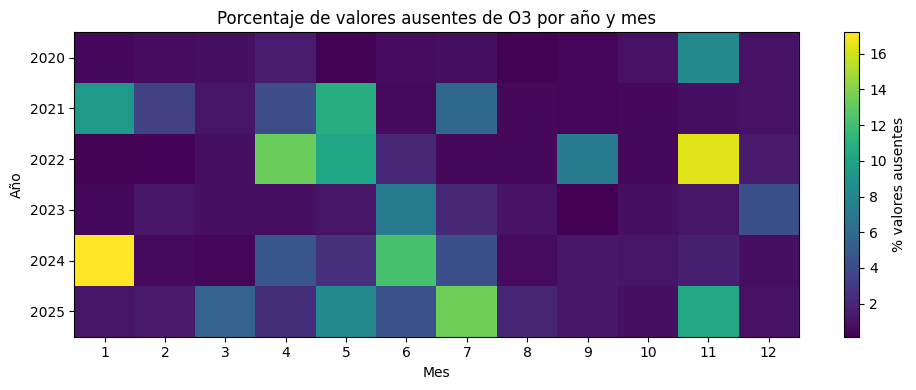

In [11]:
# A continuación, se realiza una visualización de los valores ausentes por año y mes.
# La figura que se obtenga ayudará a identificar si hay meses problemáticos.
fig, ax = plt.subplots(figsize=(10, 4))

image = ax.imshow(missing_by_month.values, aspect="auto")

ax.set_title("Porcentaje de valores ausentes de O3 por año y mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")

ax.set_xticks(np.arange(len(missing_by_month.columns)))
ax.set_xticklabels(missing_by_month.columns)

ax.set_yticks(np.arange(len(missing_by_month.index)))
ax.set_yticklabels(missing_by_month.index)

fig.colorbar(image, ax=ax, label="% valores ausentes")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_missing_by_month.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [12]:
# Se resume cada bloque cronológico considerado para el pipeline.
# La tabla permitirá comparar, el nivel de O3 (mediante la media y la mediana);
# la variabilidad (mediante la desviación típica, los percentiles y los máximos);
# t la cobertura que alcanzan los datos (mediante los registros disponibles y los valores ausentes).
# Esto facilitará detectar posibles diferencias entre los conjuntos de entrenamiento, calibración, validación y prueba.
split_summary = (
    split_eda_df.groupby("data_block", observed=False)
    .agg(
        start_timestamp=("timestamp", "min"),
        end_timestamp=("timestamp", "max"),
        hourly_records=("timestamp", "size"),
        observed_o3_values=("o3", "count"),
        missing_o3_values=("o3", lambda values: values.isna().sum()),
        missing_o3_percentage=("o3", lambda values: values.isna().mean() * 100),
        mean_o3=("o3", "mean"),
        median_o3=("o3", "median"),
        std_o3=("o3", "std"),
        p05_o3=("o3", lambda values: values.dropna().quantile(0.05)),
        p95_o3=("o3", lambda values: values.dropna().quantile(0.95)),
        max_o3=("o3", "max"),
    )
    .reindex(BLOCK_ORDER)
    .reset_index()
)

display(split_summary.round(2))

split_summary.to_csv(
    TABLES_DIR / "eda_external_block_summary.csv",
    index=False,
)

,data_block,start_timestamp,end_timestamp,hourly_records,observed_o3_values,missing_o3_values,missing_o3_percentage,mean_o3,median_o3,std_o3,p05_o3,p95_o3,max_o3
0,Entrenamiento (2020-2022),2020-01-01,2022-12-31 23:00:00,26304,25517,787,2.99,41.82,43.0,24.92,2.0,82.0,141.0
1,Calibración (2023),2023-01-01,2023-12-31 23:00:00,8760,8607,153,1.75,45.50,47.0,23.78,2.0,82.0,125.0
2,Validación (2024),2024-01-01,2024-12-31 23:00:00,8784,8437,347,3.95,48.55,51.0,24.99,2.0,87.0,120.0
3,Test set (2025),NaT,NaT,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Se analiza la longitud de los huecos consecutivos en las mediciones de O3,
# ya que no es lo mismo la presencia de valores ausentes aislados, que la existencia de
# tramos largos sin observaciones. Esta información será importante para decidir cómo
# tratar los valores ausentes.
missing_flags = (
    split_eda_df.set_index("timestamp")["o3"]
    .sort_index()
    .asfreq("h")
    .isna()
)

# Cada vez que cambia el estado observado/ausente, se crea un nuevo grupo para contabilizar los huecos.
run_id = missing_flags.ne(missing_flags.shift(fill_value=False)).cumsum()

missing_runs = (
    pd.DataFrame(
        {
            "is_missing": missing_flags,
            "run_id": run_id,
        }
    )
    .loc[lambda data: data["is_missing"]]
    .groupby("run_id")
    .agg(
        start_timestamp=("is_missing", lambda values: values.index.min()),
        end_timestamp=("is_missing", lambda values: values.index.max()),
        length_hours=("is_missing", "size"),
    )
    .reset_index(drop=True)
)

display(missing_runs.sort_values("length_hours", ascending=False).head(20))

missing_run_summary = pd.Series(
    {
        "number_of_missing_runs": len(missing_runs),
        "max_missing_run_hours": missing_runs["length_hours"].max() if not missing_runs.empty else 0,
        "median_missing_run_hours": missing_runs["length_hours"].median() if not missing_runs.empty else 0,
        "mean_missing_run_hours": missing_runs["length_hours"].mean() if not missing_runs.empty else 0,
        "total_missing_hours": missing_runs["length_hours"].sum() if not missing_runs.empty else 0,
    },
    name="value",
)

display(missing_run_summary.to_frame())

missing_runs.to_csv(TABLES_DIR / "eda_missing_runs.csv", index=False)
missing_run_summary.to_csv(TABLES_DIR / "eda_missing_run_summary.csv")

,start_timestamp,end_timestamp,length_hours
146,2024-01-04 12:00:00,2024-01-09 09:00:00,118
106,2022-11-03 17:00:00,2022-11-08 10:00:00,114
159,2024-05-31 12:00:00,2024-06-04 12:00:00,97
36,2021-01-29 05:00:00,2021-02-01 21:00:00,89
78,2022-04-08 03:00:00,2022-04-11 10:00:00,80
215,2025-11-14 11:00:00,2025-11-17 13:00:00,75
80,2022-04-30 10:00:00,2022-05-02 14:00:00,53
190,2025-05-21 10:00:00,2025-05-23 14:00:00,53
27,2020-11-14 08:00:00,2020-11-16 10:00:00,51
99,2022-09-11 16:00:00,2022-09-13 12:00:00,45


,value
number_of_missing_runs,218.000000
max_missing_run_hours,118.000000
median_missing_run_hours,2.000000
mean_missing_run_hours,7.642202
total_missing_hours,1666.000000


## 2. Evolución temporal de la serie y comparativa anual

Se analiza la evolución general de la serie y se comparan los años y los bloques cronológicos definidos a fin de detectar posibles cambios descriptivos del nivel de la concentración de O3 o de su dispersión. Las figuras de esta sección servirán para poner en contexto la partición temporal planteada para el proyecto.

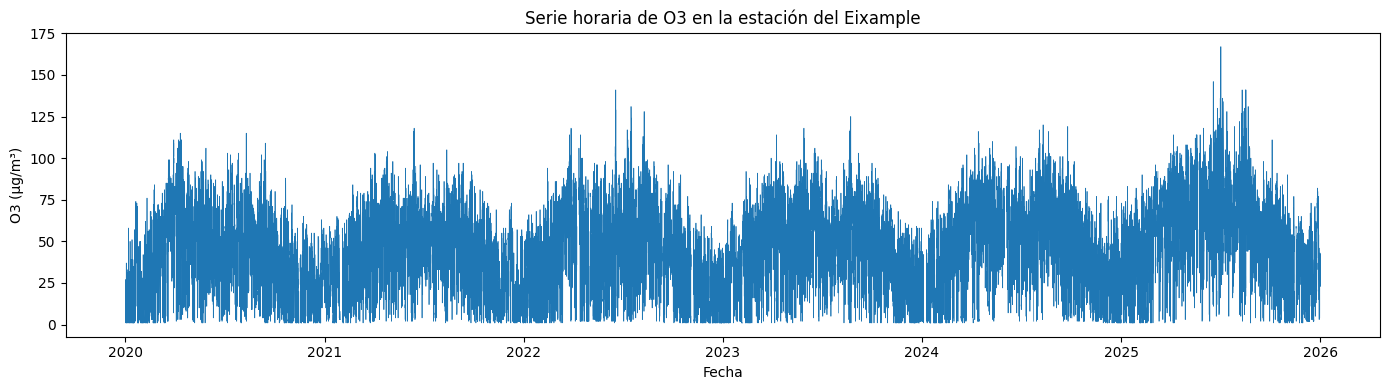

In [14]:
# Esta es la primera visualización global de la serie temporal;
# la figura permite detectar visualmente lapsos de tiempo sin registros,
# valores extremos, cambios de nivel y patrones estacionales de largo plazo.
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(hourly_df["timestamp"], hourly_df["o3"], linewidth=0.5)

ax.set_title("Serie horaria de O3 en la estación del Eixample")
ax.set_xlabel("Fecha")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

# La figura se guarda en el directorio /generated porque todavía cuenta con carácter exploratorio.
# En el notebook 01b, se guardarán las figuras finales en reports/figures/final/.
fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_full_series.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

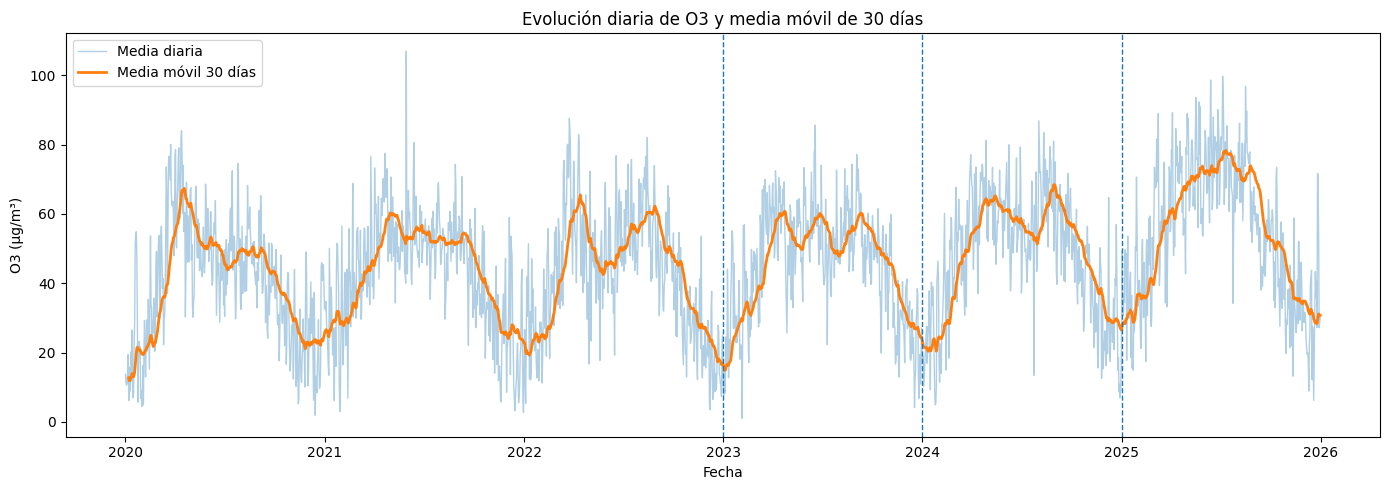

In [15]:
# Se agregan las observaciones horarias a nivel diario.
# Esto permite reducir la variabilidad hora a hora y también facilita observar la evolución general de la serie.
daily_mean_df = (
    observed_split_df
    .groupby("date")["o3"]
    .mean()
    .to_frame(name="daily_mean_o3")
    .sort_index()
)

# La media móvil de 30 días ayuda a separar el ruido horario/diario del nivel general de la concentración del O3.
daily_mean_df["rolling_30d_mean_o3"] = daily_mean_df["daily_mean_o3"].rolling(
    window=30,
    min_periods=7,
).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    daily_mean_df.index,
    daily_mean_df["daily_mean_o3"],
    linewidth=1,
    alpha=0.35,
    label="Media diaria",
)

ax.plot(
    daily_mean_df.index,
    daily_mean_df["rolling_30d_mean_o3"],
    linewidth=2,
    label="Media móvil 30 días",
)

# Se marcan las fronteras entre los bloques.
for boundary in pd.to_datetime(["2023-01-01", "2024-01-01", "2025-01-01"]):
    ax.axvline(boundary, linestyle="--", linewidth=1)

ax.set_title("Evolución diaria de O3 y media móvil de 30 días")
ax.set_xlabel("Fecha")
ax.set_ylabel("O3 (µg/m³)")
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_daily_mean_and_rolling_30d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [16]:
# Se prepara un subconjunto para comparar años sin utilizar el test de prueba (2025).
# El objetivo es estudiar si el año 2020 presenta un comportamiento distinto respecto a 2021-2024.
# Esto se debe a que, el 1 de enero de 2020 entró en vigor la zona de bajas emisiones (ZBE) en
# Barcelona y, de marzo a mayo, se tomaron medidas restrictivas como consecuencia del COVID-19.
if "split_eda_df" not in globals():
    split_eda_df = prepare_split_eda_dataframe(hourly_df)

regime_df = (
    split_eda_df[split_eda_df["year"].between(2020, 2024)]
    .dropna(subset=["o3"])
    .copy()
)

regime_df["day_of_year"] = regime_df["timestamp"].dt.dayofyear

comparison_years = sorted(regime_df["year"].unique())

print(f"Años incluidos en la comparación: {comparison_years}")
print(f"Observaciones válidas: {len(regime_df):,}")

Años incluidos en la comparación: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Observaciones válidas: 42,561


In [17]:
# Se calcula la media diaria de O3 para cada año.
# Representar los años superpuestos permite ver si 2020 sigue una trayectoria anual
# distinta a la de años posteriores.
daily_profile_by_year = (
    regime_df.groupby(["year", "date"])
    .agg(daily_mean_o3=("o3", "mean"))
    .reset_index()
)

daily_profile_by_year["day_of_year"] = daily_profile_by_year["date"].dt.dayofyear

# Se suaviza el perfil diario de cada año mediante el cálculo de una media móvil de 14 días.
# De esta forma, se reducen las oscilaciones puntuales correspondientes a cada día, lo que
# permite observar mejor la evolución general del nivel de O3 a lo largo del año.
daily_profile_by_year["rolling_14d_mean_o3"] = (
    daily_profile_by_year
    .groupby("year")["daily_mean_o3"]
    .transform(lambda values: values.rolling(window=14, center=True, min_periods=5).mean())
)

display(daily_profile_by_year.head())

daily_profile_by_year.to_csv(
    TABLES_DIR / "eda_daily_profile_by_year.csv",
    index=False,
)

,year,date,daily_mean_o3,day_of_year,rolling_14d_mean_o3
0,2020,2020-01-01,13.708333,1,12.732143
1,2020,2020-01-02,11.291667,2,11.906250
2,2020,2020-01-03,10.625000,3,12.333333
3,2020,2020-01-04,11.041667,4,11.991667
4,2020,2020-01-05,14.666667,5,12.734848


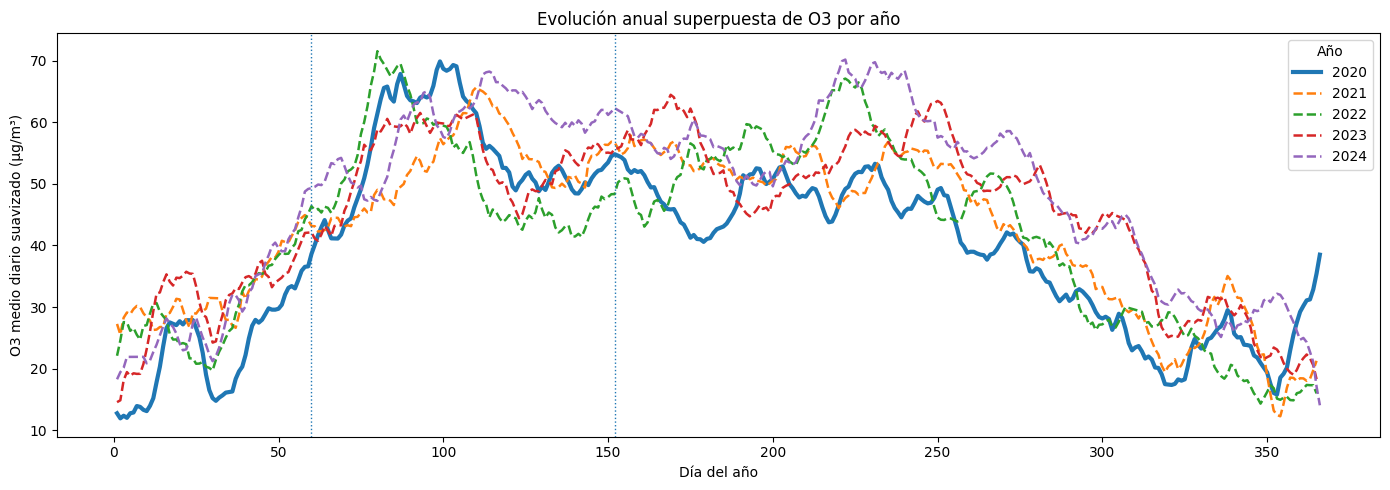

In [18]:
# Se dibuja una figura de evolución anual superpuesta.
# Cada línea representa la evolución suavizada de un año entre enero y diciembre.
fig, ax = plt.subplots(figsize=(14, 5))

for year in comparison_years:
    year_data = daily_profile_by_year[daily_profile_by_year["year"] == year]

    linewidth = 3 if year == 2020 else 1.8
    linestyle = "-" if year == 2020 else "--"

    ax.plot(
        year_data["day_of_year"],
        year_data["rolling_14d_mean_o3"],
        linewidth=linewidth,
        linestyle=linestyle,
        label=str(year),
    )

# Se marcan de forma aproximada los meses de marzo a mayo,
# periodo en el que se produjeron las restricciones por COVID-19.
ax.axvline(60, linestyle=":", linewidth=1)
ax.axvline(152, linestyle=":", linewidth=1)

ax.set_title("Evolución anual superpuesta de O3 por año")
ax.set_xlabel("Día del año")
ax.set_ylabel("O3 medio diario suavizado (µg/m³)")
ax.legend(title="Año")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_annual_overlay_by_year.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [19]:
# Se resume la distribución anual del O3 para detectar posibles cambios de nivel
# en su concentración y observar la dispersión para cada año.
# Se excluye 2025 porque se corresponde con el conjunto de prueba.
annual_summary_modeling = (
    modeling_eda_df.groupby("year")
    .agg(
        hourly_records=("timestamp", "size"),
        observed_o3_values=("o3", "count"),
        missing_o3_percentage=("o3", lambda values: values.isna().mean() * 100),
        mean_o3=("o3", "mean"),
        median_o3=("o3", "median"),
        std_o3=("o3", "std"),
        p05_o3=("o3", lambda values: values.dropna().quantile(0.05)),
        p95_o3=("o3", lambda values: values.dropna().quantile(0.95)),
        max_o3=("o3", "max"),
    )
    .reset_index()
)

display(annual_summary_modeling.round(2))

annual_summary_modeling.to_csv(
    TABLES_DIR / "eda_annual_distribution_summary_modeling_period.csv",
    index=False,
)

,year,hourly_records,observed_o3_values,missing_o3_percentage,mean_o3,median_o3,std_o3,p05_o3,p95_o3,max_o3
0,2020,8784,8667,1.33,40.11,40.0,25.19,1.0,82.0,115.0
1,2021,8760,8478,3.22,42.92,45.0,23.08,3.0,78.0,118.0
2,2022,8760,8372,4.43,42.47,43.0,26.30,2.0,85.0,141.0
3,2023,8760,8607,1.75,45.50,47.0,23.78,2.0,82.0,125.0
4,2024,8784,8437,3.95,48.55,51.0,24.99,2.0,87.0,120.0


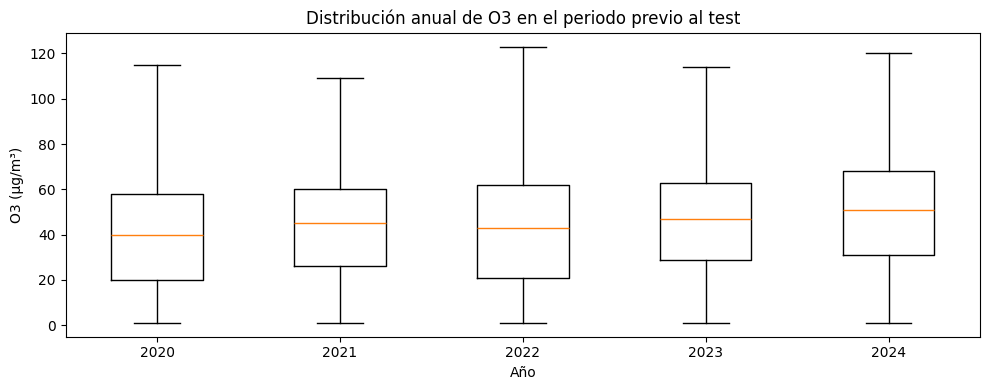

In [20]:
# Se representa la distribución de O3 por año mediante gráficos boxplot.
# Esta figura permitirá observar si se dan diferencias visibles entre años
# antes de entrenar los modelos.
years = sorted(observed_modeling_eda_df["year"].unique())

annual_boxplot_data = [
    observed_modeling_eda_df.loc[observed_modeling_eda_df["year"] == year, "o3"].to_numpy()
    for year in years
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(
    annual_boxplot_data,
    tick_labels=[str(year) for year in years],
    showfliers=False,
)

ax.set_title("Distribución anual de O3 en el periodo previo al test")
ax.set_xlabel("Año")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_boxplot_by_year_modeling_period.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3. Distribución del ozono troposférico (O3)

Se caracteriza la distribución de la concentración horaria de O3 antes de entrar en patrones temporales más específicos.

In [21]:
# Se resume la concentración observada para la concentración de O3 mediante
# la media, la desviación típica, diversos percentiles y valores extremos.
# Este resumen permite caracterizar el rango, la variabilidad y las colas de la serie.
valid_o3 = eda_df["o3"].dropna()

distribution_summary = valid_o3.describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

display(distribution_summary.to_frame(name="o3"))

distribution_summary.to_csv(TABLES_DIR / "eda_o3_distribution_summary.csv")

,o3
count,42561.000000
mean,43.897347
std,24.854590
min,1.000000
1%,1.000000
5%,2.000000
25%,25.000000
50%,45.000000
75%,62.000000
95%,83.000000


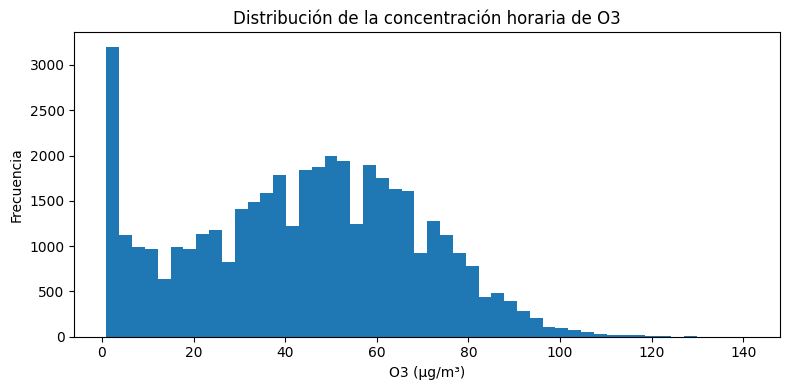

In [22]:
# Se dibuja un histograma de la concentración de O3
# a fin de observar la forma de la distribución y las mencionadas colas.
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(valid_o3, bins=50)

ax.set_title("Distribución de la concentración horaria de O3")
ax.set_xlabel("O3 (µg/m³)")
ax.set_ylabel("Frecuencia")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_histogram.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 4. Estacionalidad diaria, semanal, mensual y mes/hora de la serie temporal

Este bloque agrupa las evidencias de estacionalidad. Se estudian patrones por mes, hora del día, día de la semana y la interacción entre mes y hora.

### 4.1 Estacionalidad mensual

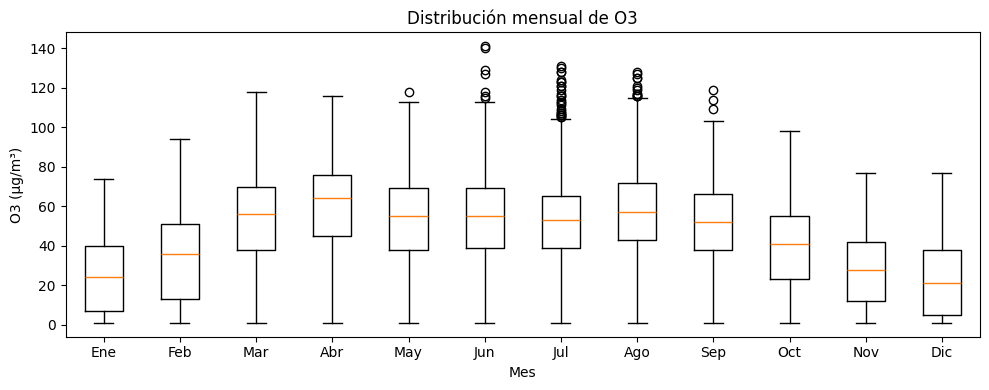

In [25]:
# Se crean gráficos boxplot que permitan observar la media mensual, la dispersión
# y la presencia de valores extremos en cada mes.
plot_df = eda_df.dropna(subset=["o3"]).copy()

month_labels = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic",
]

monthly_boxplot_data = [
    plot_df.loc[plot_df["month"] == month, "o3"].to_numpy()
    for month in range(1, 13)
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(monthly_boxplot_data, tick_labels=month_labels, showfliers=True)

ax.set_title("Distribución mensual de O3")
ax.set_xlabel("Mes")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_monthly_boxplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [26]:
# Se resumen en una tabla los valores de O3, agrupándolos según el mes.

monthly_distribution_summary = (
    plot_df.groupby("month")["o3"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        p95=lambda values: values.quantile(0.95),
        max="max",
    )
)

monthly_distribution_summary.index = month_labels

display(monthly_distribution_summary.round(2))

monthly_distribution_summary.to_csv(
    TABLES_DIR / "eda_o3_monthly_distribution_summary.csv"
)

,count,mean,median,std,q25,q75,p95,max
Ene,3513,25.05,24.0,18.72,7.0,40.0,57.0,74.0
Feb,3366,33.71,36.0,22.29,13.0,51.0,69.0,94.0
Mar,3691,52.60,56.0,23.40,38.0,70.0,86.0,118.0
Abr,3423,59.25,64.0,25.03,45.0,76.0,95.0,116.0
May,3536,52.50,55.0,23.05,38.0,69.0,86.0,118.0
Jun,3436,53.49,55.0,21.91,39.0,69.0,86.0,141.0
Jul,3619,51.74,53.0,20.67,39.0,65.0,85.0,131.0
Ago,3698,56.80,57.0,21.79,43.0,72.0,91.0,128.0
Sep,3533,50.56,52.0,21.26,38.0,66.0,83.0,119.0
Oct,3691,38.97,41.0,21.38,23.0,55.0,71.0,98.0


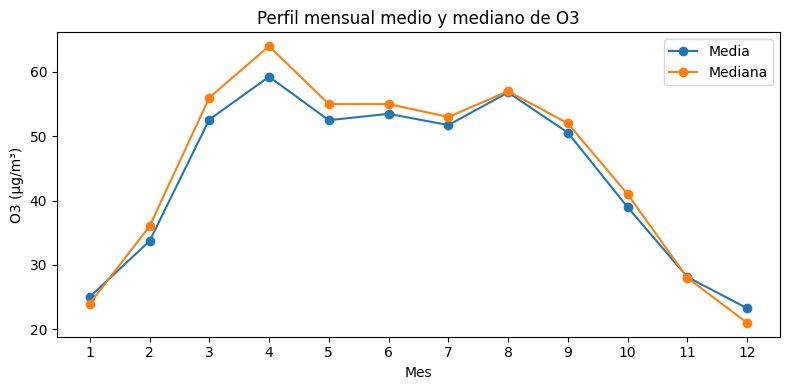

In [70]:
# Se visualiza el perfil mensual.
# Un patrón mensual claro justificaría incluir variables de calendario anual
# y también ayudaría a interpretar la formación fotoquímica del O3.
monthly_profile = (
    eda_df.groupby("month")["o3"]
    .agg(mean_o3="mean", median_o3="median", std_o3="std", count="count")
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(monthly_profile.index, monthly_profile["mean_o3"], marker="o", label="Media")
ax.plot(monthly_profile.index, monthly_profile["median_o3"], marker="o", label="Mediana")

ax.set_title("Perfil mensual medio y mediano de O3")
ax.set_xlabel("Mes")
ax.set_ylabel("O3 (µg/m³)")
ax.set_xticks(range(1, 13))
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_monthly_profile.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 4.2 Estacionalidad semanal

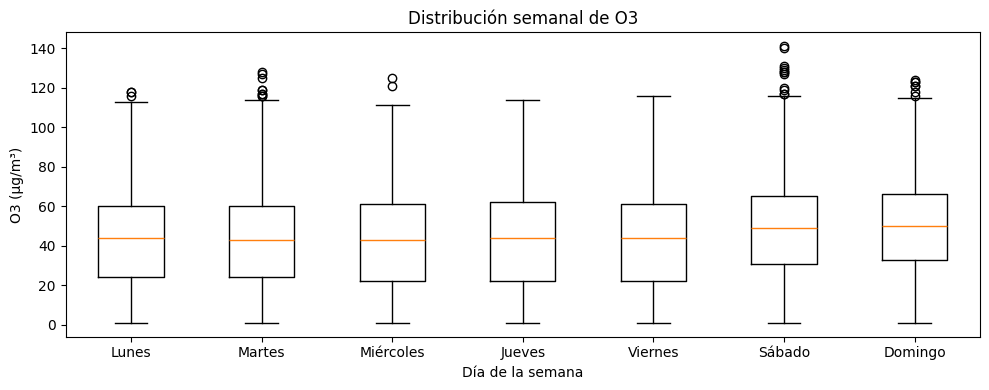

In [64]:
# Se dibuja la distribución de O3 según el día de la semana.
weekday_labels = [
    "Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo",
]

weekday_boxplot_data = [
    plot_df.loc[plot_df["day_of_week"] == day, "o3"].to_numpy()
    for day in range(7)
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(weekday_boxplot_data, tick_labels=weekday_labels, showfliers=True)

ax.set_title("Distribución semanal de O3")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_weekday_boxplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [65]:
# Se resume la concentración de O3 por día de la semana, teniendo en cuenta
# la media, la mediana, la desviación estándar y diversos cuantiles, con el objeto de
# comprobar si existen diferencias entre los días laborables y los fines de semana.
weekday_distribution_summary = (
    plot_df.groupby("day_of_week")["o3"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        p95=lambda values: values.quantile(0.95),
        max="max",
    )
)

weekday_distribution_summary.index = weekday_labels

display(weekday_distribution_summary.round(2))

weekday_distribution_summary.to_csv(
    TABLES_DIR / "eda_o3_weekday_distribution_summary.csv"
)

,count,mean,median,std,q25,q75,p95,max
Lunes,5993,42.68,44.0,24.34,24.0,60.0,81.0,118.0
Martes,6108,41.92,43.0,23.97,24.0,60.0,79.0,128.0
Miércoles,6134,42.02,43.0,24.64,22.0,61.0,81.0,125.0
Jueves,6101,42.27,44.0,25.10,22.0,62.0,82.0,114.0
Viernes,6088,42.23,44.0,25.08,22.0,61.0,83.0,116.0
Sábado,6106,47.59,49.0,25.16,31.0,65.0,88.0,141.0
Domingo,6031,48.63,50.0,24.66,33.0,66.0,86.5,124.0


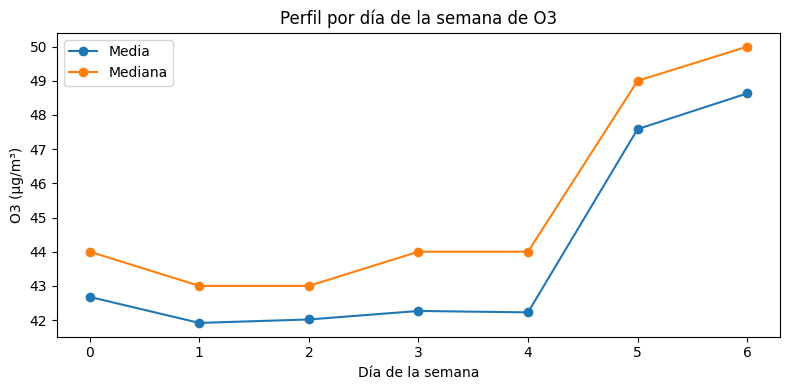

In [75]:
# Se dibuja la gráfica de los perfiles por día de la semana para la media y la mediana.
# Si aparece un patrón claro entre días laborables y fines de semana,
# se justifica incluir variables de calendario como day_of_week o is_weekend.
weekday_profile = (
    eda_df.groupby("day_of_week")["o3"]
    .agg(mean_o3="mean", median_o3="median", std_o3="std", count="count",)
    .reindex(range(7))
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(weekday_profile.index, weekday_profile["mean_o3"], marker="o", label="Media",)
ax.plot(weekday_profile.index, weekday_profile["median_o3"], marker="o", label="Mediana",)

ax.set_title("Perfil por día de la semana de O3")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("O3 (µg/m³)")
ax.set_xticks(range(7))
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_weekday_profile.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 4.3 Estacionalidad horaria

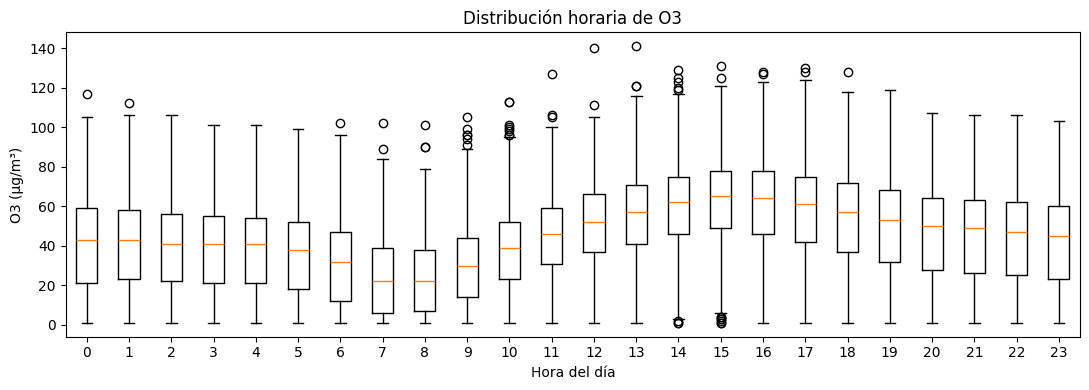

In [29]:
# Se analiza la distribución de O3 según la hora del día.
# Este gráfico permite comprobar la estacionalidad diaria mediante la observación
# de la media la mediana, la dispersión y los valores atípicos de cada hora.
hourly_boxplot_data = [
    plot_df.loc[plot_df["hour"] == hour, "o3"].to_numpy()
    for hour in range(24)
]

fig, ax = plt.subplots(figsize=(11, 4))

ax.boxplot(
    hourly_boxplot_data,
    tick_labels=range(24),
    showfliers=True,
)

ax.set_title("Distribución horaria de O3")
ax.set_xlabel("Hora del día")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_hourly_boxplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [30]:
# Se resumen los valores de O3 según la hora del día.
# Para cada hora, se calcula el número de observaciones, la media,
# la mediana, la variabilidad y varios percentiles.
# Esta tabla facilitará la interpretación del anterior gráfico boxplot y a
# justificar el uso de la hora del día como variable predictiva.
hourly_distribution_summary = (
    plot_df.groupby("hour")["o3"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        p95=lambda values: values.quantile(0.95),
        max="max",
    )
)

display(hourly_distribution_summary.round(2))

hourly_distribution_summary.to_csv(
    TABLES_DIR / "eda_o3_hourly_distribution_summary.csv"
)

,count,mean,median,std,q25,q75,p95,max
hour,,,,,,,,
0,1788,40.41,43.0,23.96,21.0,59.0,77.00,117.0
1,1783,40.51,43.0,23.32,23.0,58.0,75.00,112.0
2,1781,39.39,41.0,22.85,22.0,56.0,75.00,106.0
3,1787,38.50,41.0,22.80,21.0,55.0,75.00,101.0
4,1787,38.17,41.0,22.62,21.0,54.0,74.00,101.0
5,1785,36.00,38.0,21.93,18.0,52.0,70.00,99.0
6,1785,31.14,32.0,21.03,12.0,47.0,66.00,102.0
7,1784,24.76,22.0,19.30,6.0,39.0,58.00,102.0
8,1778,24.56,22.0,19.10,7.0,38.0,59.15,101.0


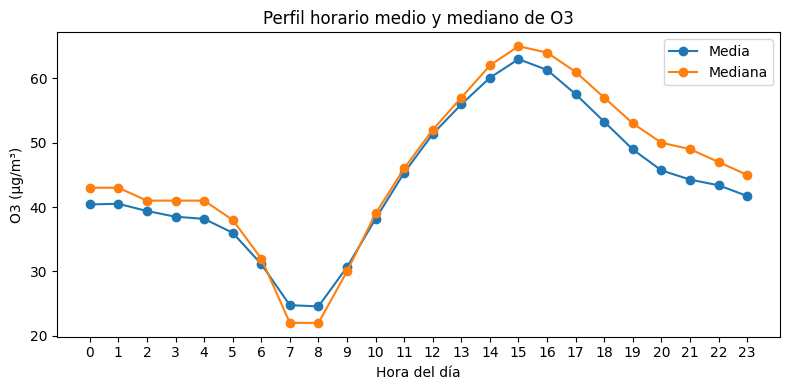

In [71]:
# Se dibuja la gráfica de los perfiles horarios para la media y la mediana.
# Si aparece un patrón claro según la hora del día, quedaría incluir variables
# de calendario y retardos asociados al ciclo diario.
hourly_profile = (
    eda_df.groupby("hour")["o3"]
    .agg(mean_o3="mean", median_o3="median", std_o3="std", count="count")
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hourly_profile.index, hourly_profile["mean_o3"], marker="o", label="Media")
ax.plot(hourly_profile.index, hourly_profile["median_o3"], marker="o", label="Mediana")

ax.set_title("Perfil horario medio y mediano de O3")
ax.set_xlabel("Hora del día")
ax.set_ylabel("O3 (µg/m³)")
ax.set_xticks(range(0, 24))
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_hourly_profile.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 4.3 Estacionalidad por día de la semana

In [31]:
# Se resume la concentración de O3 por día de la semana, teniendo en cuenta
# la media, la mediana y la desviación estándar, con el objeto de
# comprobar si existen diferencias entre los días laborables y los fines de semana.
weekday_profile = (
    eda_df.groupby("day_of_week")["o3"]
    .agg(mean_o3="mean", median_o3="median", std_o3="std", count="count")
)

weekday_names = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

weekday_profile = weekday_profile.rename(index=weekday_names)

display(weekday_profile.round(2))

weekday_profile.to_csv(TABLES_DIR / "eda_weekday_profile.csv")

,mean_o3,median_o3,std_o3,count
day_of_week,,,,
Lunes,42.68,44.0,24.34,5993
Martes,41.92,43.0,23.97,6108
Miércoles,42.02,43.0,24.64,6134
Jueves,42.27,44.0,25.10,6101
Viernes,42.23,44.0,25.08,6088
Sábado,47.59,49.0,25.16,6106
Domingo,48.63,50.0,24.66,6031


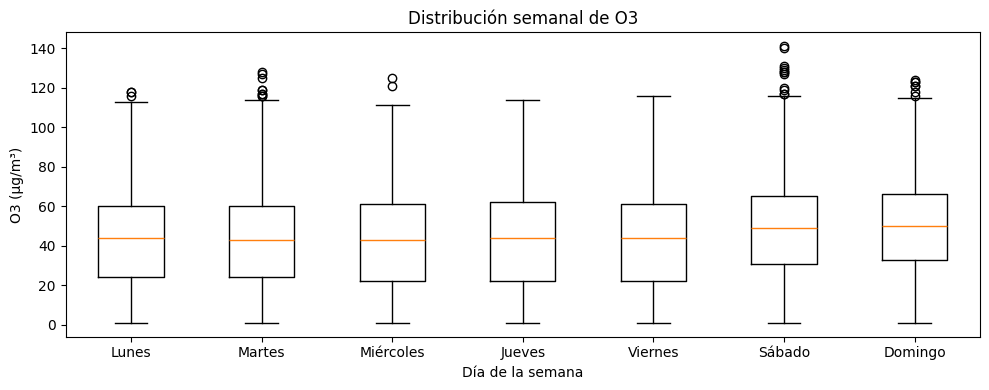

In [32]:
# Se dibuja la distribución de O3 según el día de la semana.
weekday_labels = [
    "Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo",
]

weekday_boxplot_data = [
    plot_df.loc[plot_df["day_of_week"] == day, "o3"].to_numpy()
    for day in range(7)
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(weekday_boxplot_data, tick_labels=weekday_labels, showfliers=True)

ax.set_title("Distribución semanal de O3")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_weekday_boxplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [33]:
# Se resumen los valores de O3 agrupándolos por el día de la semana.
weekday_distribution_summary = (
    plot_df.groupby("day_of_week")["o3"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        p95=lambda values: values.quantile(0.95),
        max="max",
    )
)

weekday_distribution_summary.index = weekday_labels

display(weekday_distribution_summary.round(2))

weekday_distribution_summary.to_csv(
    TABLES_DIR / "eda_o3_weekday_distribution_summary.csv"
)

,count,mean,median,std,q25,q75,p95,max
Lunes,5993,42.68,44.0,24.34,24.0,60.0,81.0,118.0
Martes,6108,41.92,43.0,23.97,24.0,60.0,79.0,128.0
Miércoles,6134,42.02,43.0,24.64,22.0,61.0,81.0,125.0
Jueves,6101,42.27,44.0,25.10,22.0,62.0,82.0,114.0
Viernes,6088,42.23,44.0,25.08,22.0,61.0,83.0,116.0
Sábado,6106,47.59,49.0,25.16,31.0,65.0,88.0,141.0
Domingo,6031,48.63,50.0,24.66,33.0,66.0,86.5,124.0


### 4.4 Interacción entre mes y hora

In [34]:
# Se calcula la concentración media del O3 para cada combinación posible de mes y hora.
# El resultado permitirá estudiar si el ciclo diario cambia según la época del año.
month_hour_matrix = (
    plot_df.groupby(["month", "hour"])["o3"]
    .mean()
    .unstack("hour")
    .reindex(index=range(1, 13), columns=range(24))
)

display(month_hour_matrix.round(2))

month_hour_matrix.to_csv(TABLES_DIR / "eda_o3_month_hour_matrix.csv")

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,,,,
1,22.01,24.51,25.47,26.75,27.41,26.86,22.72,16.80,14.06,16.80,21.59,28.08,33.12,34.22,37.52,38.94,35.49,29.59,23.19,18.88,17.77,19.14,20.04,21.12
2,26.97,28.50,29.25,29.87,29.75,27.77,24.09,17.82,15.65,20.11,29.53,37.81,41.47,46.90,52.30,54.73,52.87,48.27,41.62,36.79,32.57,29.39,28.70,27.44
3,49.24,48.58,47.82,47.75,48.39,46.04,39.14,30.88,30.86,37.86,46.47,53.53,60.19,65.23,70.05,71.89,70.66,67.59,62.79,56.89,55.09,53.43,53.00,50.17
4,56.95,55.94,52.60,51.85,49.31,45.67,40.06,31.43,31.08,39.89,48.63,55.75,64.89,71.50,76.38,80.72,81.05,78.78,76.43,72.44,68.64,66.58,63.69,60.83
5,49.57,46.85,42.93,40.90,38.79,37.01,32.04,26.17,29.86,38.73,44.76,53.09,58.72,65.25,70.38,74.55,73.99,71.63,69.35,65.35,60.28,58.85,57.42,54.07
6,51.39,49.64,46.66,43.37,42.81,37.65,33.14,29.77,32.81,38.80,47.50,55.91,62.55,67.50,70.04,73.19,71.90,69.79,67.05,63.58,60.64,58.90,55.61,53.48
7,49.21,48.01,45.35,42.03,40.40,37.17,31.79,27.82,31.15,38.75,46.69,54.93,61.11,66.38,68.66,70.96,69.95,68.45,65.68,60.89,56.54,55.08,53.84,51.65
8,51.86,50.59,49.03,47.06,46.59,43.81,38.72,32.41,35.22,43.64,50.45,57.87,66.50,72.12,76.09,78.31,76.98,74.08,70.34,66.32,62.34,60.10,58.15,54.90
9,48.52,48.23,46.29,44.37,43.03,40.95,36.13,27.55,24.39,33.18,41.61,48.70,55.27,61.54,67.32,72.02,71.87,68.91,64.39,59.34,54.87,53.27,52.06,49.89


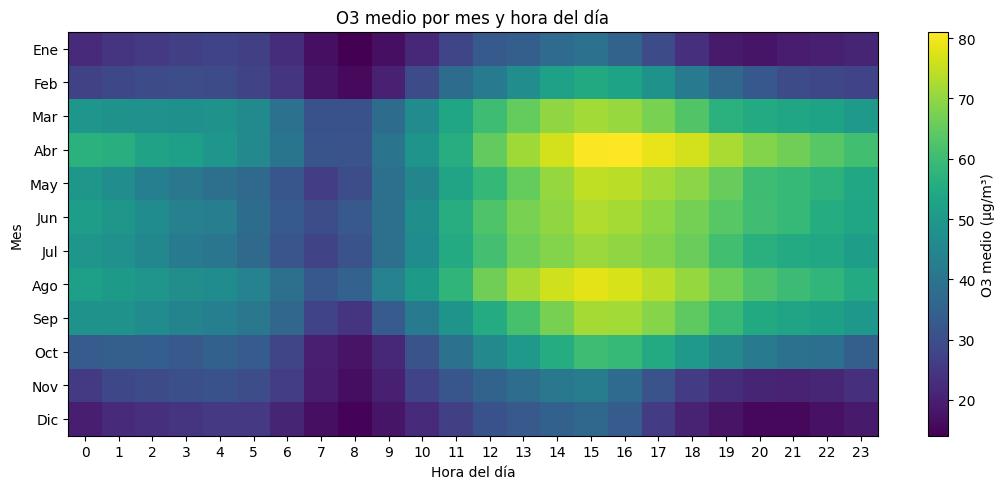

In [35]:
# Se dibuja un mapa de calor del O3 medio por mes y hora.
# Como se verá, las filas representan meses y las columnas horas del día.
# Además, los patrones de color permiten identificar cuándo se concentran los valores más altos.
fig, ax = plt.subplots(figsize=(11, 5))

image = ax.imshow(month_hour_matrix.values, aspect="auto")

ax.set_title("O3 medio por mes y hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Mes")

ax.set_xticks(np.arange(24))
ax.set_xticklabels(range(24))

ax.set_yticks(np.arange(12))
ax.set_yticklabels(month_labels)

fig.colorbar(image, ax=ax, label="O3 medio (µg/m³)")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_month_hour_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Ene,52.0,54.0,54.3,54.9,56.6,52.4,50.0,44.0,37.5,43.0,46.0,46.6,50.8,53.7,57.0,58.0,54.5,51.4,47.8,46.4,46.8,49.4,51.6,50.4
Feb,59.0,60.0,58.0,62.0,60.0,58.0,51.0,45.0,39.0,43.1,52.0,59.5,62.0,67.2,72.3,73.0,76.0,73.0,62.0,60.0,58.0,57.0,55.9,54.9
Mar,79.0,80.0,80.6,78.6,79.2,77.6,69.6,62.6,60.2,64.6,70.9,76.0,80.4,85.0,89.0,88.0,89.4,86.2,83.6,81.2,80.0,79.0,77.6,76.0
Abr,81.0,82.0,80.4,80.8,76.0,74.0,69.9,66.0,61.0,68.0,71.0,74.0,88.0,94.2,96.0,100.0,100.0,99.4,97.0,92.0,86.0,86.7,85.7,85.0
May,73.2,71.0,67.3,67.0,65.0,64.0,60.0,52.0,54.0,61.0,66.8,77.0,79.0,82.8,88.0,93.3,91.0,89.4,85.2,85.0,80.0,77.2,78.0,75.3
Jun,74.0,71.7,71.0,66.7,66.7,61.0,56.7,54.0,58.7,61.0,69.6,76.0,82.0,88.0,88.0,93.7,88.7,89.0,85.5,83.5,80.0,77.5,76.6,76.0
Jul,67.0,66.0,65.0,61.0,59.9,59.0,53.8,50.0,53.0,60.0,68.6,76.0,82.0,89.5,89.4,89.1,87.0,87.8,84.8,77.0,73.0,72.8,71.0,70.9
Ago,75.0,74.6,72.0,71.6,68.6,67.0,61.4,55.2,59.0,67.8,74.1,81.0,88.0,92.0,96.8,97.7,95.0,92.6,88.6,85.0,79.0,79.6,80.0,78.0
Sep,70.3,70.3,68.0,66.0,63.0,60.3,55.0,50.3,49.3,54.2,64.6,71.0,76.0,83.0,85.4,90.0,89.3,87.3,84.0,77.0,73.0,72.0,73.3,72.0
Oct,60.0,60.6,60.1,60.0,60.6,56.2,54.8,46.6,42.2,42.7,52.0,58.0,65.1,69.0,73.0,79.0,79.7,74.6,68.6,65.6,63.0,62.0,62.6,60.0


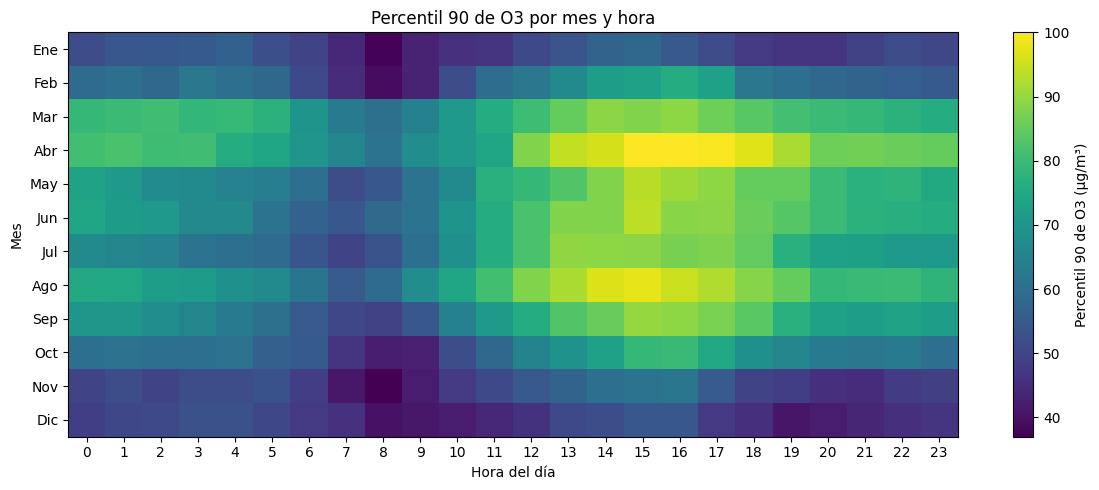

In [36]:
# Se calcula el percentil 90 de O3 para cada combinación mes-hora.
# Se usa solo el periodo 2020-2024 para evitar que el conjunto de prueba influya
# en la toma de decisiones respecto al modelado.
# Este resumen ayuda a detectar franjas donde se concentren valores relativamente elevados de O3.
month_hour_p90 = (
    observed_modeling_eda_df
    .pivot_table(
        index="month",
        columns="hour",
        values="o3",
        aggfunc=lambda values: values.quantile(0.90),
    )
    .reindex(index=range(1, 13), columns=range(24))
)

month_hour_p90.index = [MONTH_LABELS[month] for month in month_hour_p90.index]

display(month_hour_p90.round(2))

month_hour_p90.to_csv(
    TABLES_DIR / "eda_month_hour_p90.csv",
    index=True,
)

plot_heatmap(
    matrix=month_hour_p90,
    title="Percentil 90 de O3 por mes y hora",
    colorbar_label="Percentil 90 de O3 (µg/m³)",
    output_path=FIGURES_GENERATED_DIR / "eda_month_hour_p90_heatmap.png",
    value_format=".1f",
    xlabel="Hora del día",
    ylabel="Mes",
    annotate=False,
    figsize=(12, 5),
)

## 5. Autocorrelación y estacionariedad

En esta sección, se estudiará la dependencia temporal de la serie para justificar el uso de retardos y de variables temporales.

### 5.1 Autocorrelación de la serie original

In [37]:
# A continuación, se observará la correlación del O3 actual con sus valores en horas anteriores.
# Para calcular esta correlación correctamente, la serie deberá tener una observación en cada hora;
# como hay algunos valores de O3 ausentes, se rellenarán temporalmente, pero solo para este análisis.
o3_series = (
    eda_df.set_index("timestamp")["o3"]
    .asfreq("h")
    .interpolate(limit_direction="both")
)

# Se calcula la autocorrelación hasta 7 días atrás.
max_lag = 24 * 7
acf_values = acf(o3_series, nlags=max_lag, fft=True)

selected_lags = [1, 2, 3, 4, 6, 12, 24, 48, 72, 168]

acf_summary = pd.DataFrame(
    {
        "lag_hours": selected_lags,
        "autocorrelation": [acf_values[lag] for lag in selected_lags],
    }
)

display(acf_summary.round(4))

acf_summary.to_csv(TABLES_DIR / "eda_selected_lag_autocorrelation.csv", index=False)

,lag_hours,autocorrelation
0,1,0.9252
1,2,0.8207
2,3,0.7166
3,4,0.6169
4,6,0.4477
5,12,0.2626
6,24,0.6340
7,48,0.5502
8,72,0.5212
9,168,0.5246


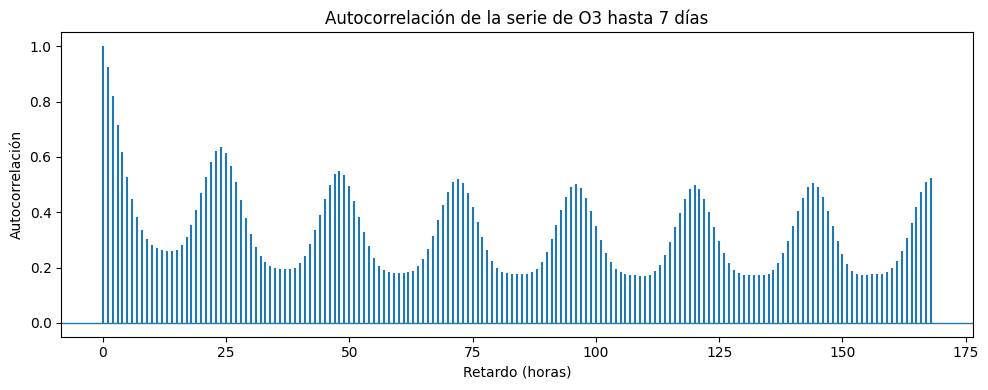

In [38]:
# Visualización de la autocorrelación hasta 7 días en el pasado.
# Los picos en los retardos de 24, 48 o 168 horas ayudarán a identificar ciclos diarios o semanales,
# justificar los retardos (o lags) candidatos y fundamentar el entrenamiento del modelo base ingenuo estacional.
fig, ax = plt.subplots(figsize=(10, 4))

lags = np.arange(len(acf_values))

ax.vlines(lags, ymin=0, ymax=acf_values)
ax.axhline(0, linewidth=1)

ax.set_title("Autocorrelación de la serie de O3 hasta 7 días")
ax.set_xlabel("Retardo (horas)")
ax.set_ylabel("Autocorrelación")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_acf_7_days.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 5.2 Tests de estacionariedad y correlogramas de la serie diferenciada

Aunque los modelos principales del TFG no requieren estacionariedad estricta, el análisis de estacionariedad resulta útil para caracterizar la serie.

A diferencia de modelos estadísticos clásicos como ARIMA, la regresión cuantílica, LightGBM y CatBoost se entrenan sobre una matriz supervisada de variables temporales, retardos y ventanas móviles.

Por tanto, no necesitan que la serie mantenga media y varianza constantes en todo el periodo, aunque sí pueden verse afectados por cambios temporales de distribución.

Por este motivo, la estacionariedad se analiza como una evidencia exploratoria adicional y no como una condición previa indispensable para entrenar los modelos.

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, pacf
import warnings

In [40]:
# Se usa el periodo previo al conjunto de prueba para estudiar la estacionariedad y la autocorrelación.
# Así se evita que 2025 influya en decisiones de modelado.
stationarity_series = (
    modeling_eda_df.set_index("timestamp")["o3"]
    .sort_index()
    .asfreq("h")
    .interpolate(limit_direction="both")
)

# Se crean transformaciones sencillas de la serie:
# a) original: serie horaria de O3 sin aplicar diferenciación.
# b) diff_1h: diferencia con la hora anterior.
# c) diff_24h: diferencia con la misma hora del día anterior.
# d) diff_1h_24h: combinación de diferencia horaria y diaria.
stationarity_candidates = {
    "original": stationarity_series.dropna(),
    "diff_1h": stationarity_series.diff(1).dropna(),
    "diff_24h": stationarity_series.diff(24).dropna(),
    "diff_1h_24h": stationarity_series.diff(1).diff(24).dropna(),
}

for name, series in stationarity_candidates.items():
    print(f"{name}: {len(series):,} observaciones")

original: 43,848 observaciones
diff_1h: 43,847 observaciones
diff_24h: 43,824 observaciones
diff_1h_24h: 43,823 observaciones


In [41]:
def run_stationarity_tests(series: pd.Series, series_name: str) -> dict:
    """Ejecuta los tests ADF y KPSS sobre una serie temporal.

    ADF:
    - Hipótesis nula: la serie tiene raíz unitaria, esto es, no es estacionaria.
    - Un p-value bajo sugeriría rechazar la no estacionariedad.

    KPSS:
    - Hipótesis nula: la serie es estacionaria.
    - Un p-value alto sugeriría que no hay una evidencia fuerte contra la estacionariedad.
    """
    clean_series = series.dropna()

    adf_statistic, adf_pvalue, *_ = adfuller(clean_series, autolag="AIC")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_statistic, kpss_pvalue, *_ = kpss(
            clean_series,
            regression="c",
            nlags="auto",
        )

    return {
        "series": series_name,
        "adf_statistic": adf_statistic,
        "adf_pvalue": adf_pvalue,
        "kpss_statistic": kpss_statistic,
        "kpss_pvalue": kpss_pvalue,
    }


stationarity_test_results = pd.DataFrame(
    [
        run_stationarity_tests(series, name)
        for name, series in stationarity_candidates.items()
    ]
)

display(stationarity_test_results.round(4))

stationarity_test_results.to_csv(
    TABLES_DIR / "eda_stationarity_tests.csv",
    index=False,
)

,series,adf_statistic,adf_pvalue,kpss_statistic,kpss_pvalue
0,original,-12.6684,0.0,1.1521,0.01
1,diff_1h,-39.5458,0.0,0.0180,0.10
2,diff_24h,-35.7271,0.0,0.0098,0.10
3,diff_1h_24h,-49.5220,0.0,0.0048,0.10


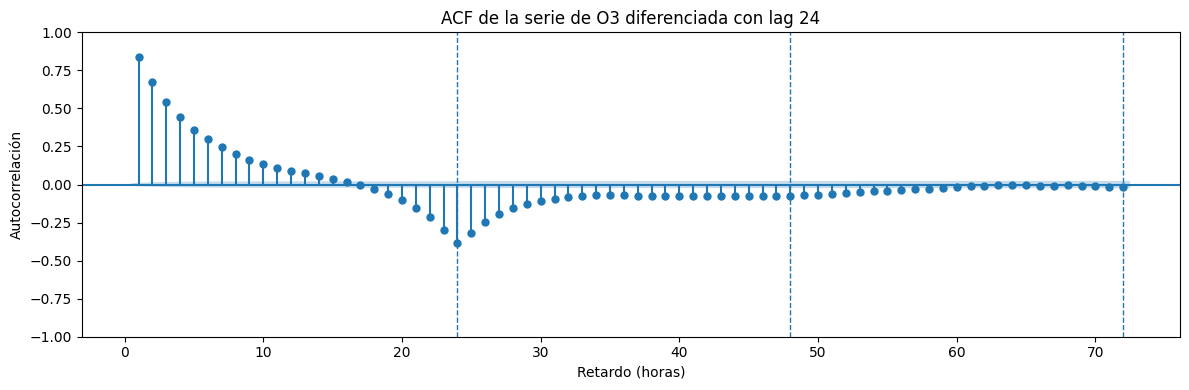

In [42]:
# Para los correlogramas se utiliza la serie diferenciada respecto a la misma hora
# del día anterior. Esta transformación reduce el ciclo diario dominante y permite
# observar qué estructura temporal quedará después de eliminar parte de la estacionalidad.
correlogram_series = stationarity_candidates["diff_24h"]

max_lag = 72

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(
    correlogram_series,
    lags=max_lag,
    ax=ax,
    zero=False,
)

for lag in [24, 48, 72]:
    ax.axvline(lag, linestyle="--", linewidth=1)

ax.set_title("ACF de la serie de O3 diferenciada con lag 24")
ax.set_xlabel("Retardo (horas)")
ax.set_ylabel("Autocorrelación")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_diff24_acf.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

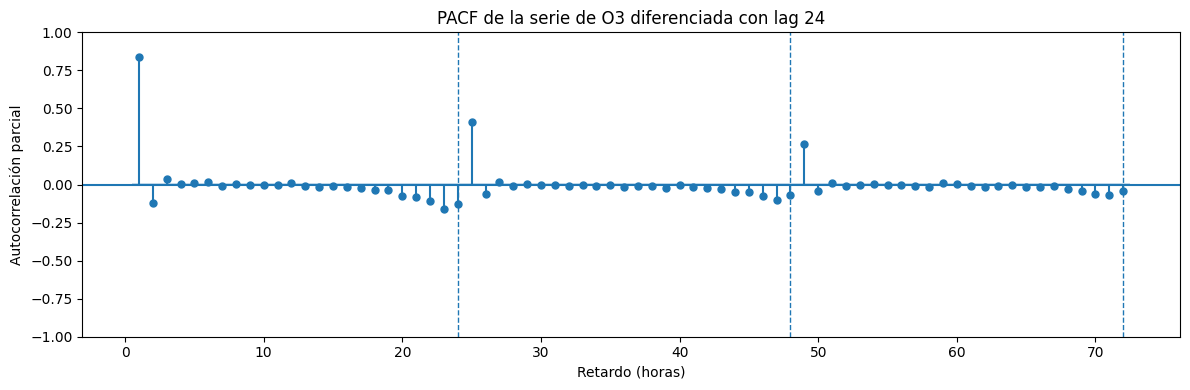

In [43]:
fig, ax = plt.subplots(figsize=(12, 4))

plot_pacf(
    correlogram_series,
    lags=max_lag,
    ax=ax,
    zero=False,
    method="ywm",
)

for lag in [24, 48, 72]:
    ax.axvline(lag, linestyle="--", linewidth=1)

ax.set_title("PACF de la serie de O3 diferenciada con lag 24")
ax.set_xlabel("Retardo (horas)")
ax.set_ylabel("Autocorrelación parcial")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_diff24_pacf.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [44]:
# Se resumen algunos retardos relevantes de la serie diferenciada.
# Esto permitirá interpretar los correlogramas sin depender solo de la figura.
selected_lags_stationary = [1, 2, 3, 4, 6, 12, 24, 48, 72]

acf_diff24_values = acf(
    correlogram_series,
    nlags=max_lag,
    fft=True,
)

pacf_diff24_values = pacf(
    correlogram_series,
    nlags=max_lag,
    method="ywm",
)

stationary_correlogram_summary = pd.DataFrame(
    {
        "lag_hours": selected_lags_stationary,
        "acf_diff24": [acf_diff24_values[lag] for lag in selected_lags_stationary],
        "pacf_diff24": [pacf_diff24_values[lag] for lag in selected_lags_stationary],
    }
)

display(stationary_correlogram_summary.round(4))

stationary_correlogram_summary.to_csv(
    TABLES_DIR / "eda_stationary_correlogram_summary.csv",
    index=False,
)

,lag_hours,acf_diff24,pacf_diff24
0,1,0.8411,0.8411
1,2,0.6717,-0.1222
2,3,0.5424,0.0385
3,4,0.4405,0.0004
4,6,0.2989,0.0144
5,12,0.0905,0.0103
6,24,-0.3867,-0.1250
7,48,-0.0751,-0.0672
8,72,-0.0133,-0.0439


## 6. Diagnóstico exploratorio de reglas ingenuas estacionales

Con carácter previo a la evaluación formal de los modelos seleccionados, se analizan algunas reglas ingenuas estacionales simples basadas en valores pasados de O3. En particular, se comparará la regla diaria `lag_24` con la regla semanal `lag_168` y se estudiarán los residuos de la variante diaria para caracterizar la dificultad predictiva de la serie y motivar el uso posterior de modelos supervisados e intervalos de predicción.

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats

In [46]:
# Se construyen dos versiones simples del modelo base ingenuo estacional:
# a) lag 24: utiliza la misma hora del día anterior.
# b) lag 168: utiliza la misma hora de la semana anterior.
#
# Esta comparación permite comprobar si es la estacionalidad diaria o la semanal
# la que ofrece una mejor referencia básica para la serie de O3.

baseline_df = (
    eda_df[["timestamp", "o3"]]
    .set_index("timestamp")
    .sort_index()
    .asfreq("h")
)

baseline_df["prediction_lag_24"] = baseline_df["o3"].shift(24)
baseline_df["prediction_lag_168"] = baseline_df["o3"].shift(168)

baseline_eval_df = baseline_df.dropna(
    subset=["o3", "prediction_lag_24", "prediction_lag_168"]
).copy()

baseline_results = []

for prediction_column in ["prediction_lag_24", "prediction_lag_168"]:
    residuals = baseline_eval_df["o3"] - baseline_eval_df[prediction_column]

    baseline_results.append(
        {
            "baseline": prediction_column,
            "mae": mean_absolute_error(
                baseline_eval_df["o3"],
                baseline_eval_df[prediction_column],
            ),
            "rmse": np.sqrt(
                mean_squared_error(
                    baseline_eval_df["o3"],
                    baseline_eval_df[prediction_column],
                )
            ),
            "residual_mean": residuals.mean(),
            "residual_std": residuals.std(),
            "residual_skewness": stats.skew(residuals),
            "residual_kurtosis": stats.kurtosis(residuals),
        }
    )

baseline_comparison = pd.DataFrame(baseline_results)

display(baseline_comparison.round(4))

baseline_comparison.to_csv(
    TABLES_DIR / "eda_seasonal_naive_baseline_comparison.csv",
    index=False,
)

,baseline,mae,rmse,residual_mean,residual_std,residual_skewness,residual_kurtosis
0,prediction_lag_24,16.2020,21.3016,-0.0201,21.3019,0.0645,0.6812
1,prediction_lag_168,18.7925,24.0627,0.0348,24.0630,-0.0031,0.1569


In [47]:
# Se calculan los residuos de la regla ingenua estacional diaria basada en lag_24.
# Esta regla usa como predicción el valor de O3 observado en la misma hora del día anterior.
#
# El residuo mide la diferencia entre el valor real de O3 y esa predicción;
# analizar estos errores permite comprobar si son pequeños y tienen un carácter regular,
# o si, por el contrario, presentan valores extremos y cambios de variabilidad según el contexto.
# Si los errores no son regulares, serán necesarios intervalos más flexibles que sean capaces
# de reflejar mejor el rango plausible en el que podría caer una observación futura.

baseline_eval_df["residual_lag_24"] = (
    baseline_eval_df["o3"] - baseline_eval_df["prediction_lag_24"]
)

baseline_eval_df["absolute_residual_lag_24"] = baseline_eval_df[
    "residual_lag_24"
].abs()

residual_summary = pd.Series(
    {
        "mean": baseline_eval_df["residual_lag_24"].mean(),
        "std": baseline_eval_df["residual_lag_24"].std(),
        "skewness": stats.skew(baseline_eval_df["residual_lag_24"]),
        "kurtosis": stats.kurtosis(baseline_eval_df["residual_lag_24"]),
        "p01": baseline_eval_df["residual_lag_24"].quantile(0.01),
        "p05": baseline_eval_df["residual_lag_24"].quantile(0.05),
        "p50": baseline_eval_df["residual_lag_24"].quantile(0.50),
        "p95": baseline_eval_df["residual_lag_24"].quantile(0.95),
        "p99": baseline_eval_df["residual_lag_24"].quantile(0.99),
        "min": baseline_eval_df["residual_lag_24"].min(),
        "max": baseline_eval_df["residual_lag_24"].max(),
    },
    name="residual_lag_24",
)

display(residual_summary.round(4).to_frame())

residual_summary.to_csv(
    TABLES_DIR / "eda_seasonal_naive_residual_summary.csv"
)

,residual_lag_24
mean,-0.0201
std,21.3019
skewness,0.0645
kurtosis,0.6812
p01,-52.0000
p05,-36.0000
p50,0.0000
p95,36.0000
p99,54.0000
min,-89.0000


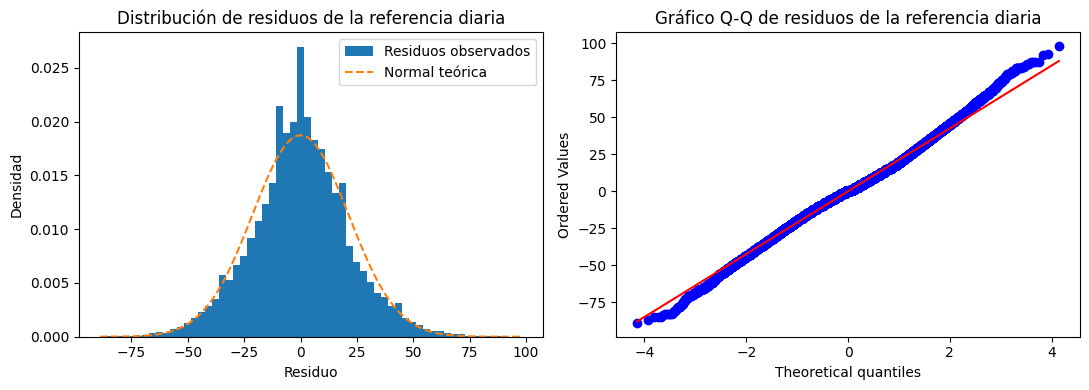

In [48]:
# Se dibuja la distribución de residuos de la referencia diaria y su gráfico Q-Q.

residuals_lag_24 = baseline_eval_df["residual_lag_24"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(residuals_lag_24, bins=60, density=True, label="Residuos observados")

x_values = np.linspace(
    residuals_lag_24.min(),
    residuals_lag_24.max(),
    500,
)

normal_density = stats.norm.pdf(
    x_values,
    loc=residuals_lag_24.mean(),
    scale=residuals_lag_24.std(),
)

axes[0].plot(
    x_values,
    normal_density,
    linestyle="--",
    label="Normal teórica",
)

axes[0].set_title("Distribución de residuos de la referencia diaria")
axes[0].set_xlabel("Residuo")
axes[0].set_ylabel("Densidad")
axes[0].legend()

stats.probplot(residuals_lag_24, dist="norm", plot=axes[1])
axes[1].set_title("Gráfico Q-Q de residuos de la referencia diaria")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_seasonal_naive_residuals_normality.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [49]:
# Se estudia si el error absoluto de la referencia diaria cambia según la hora.
# Si el error es mayor en determinadas franjas horarias, habrá evidencia de
# heterocedasticidad temporal: esto es, la incertidumbre no es constante a lo largo del día.

residual_context_df = baseline_eval_df.reset_index().copy()
residual_context_df["hour"] = residual_context_df["timestamp"].dt.hour
residual_context_df["month"] = residual_context_df["timestamp"].dt.month
residual_context_df["day_of_week"] = residual_context_df["timestamp"].dt.dayofweek

baseline_error_by_hour = (
    residual_context_df.groupby("hour")["absolute_residual_lag_24"]
    .agg(
        mean_absolute_residual="mean",
        median_absolute_residual="median",
        p95_absolute_residual=lambda values: values.quantile(0.95),
        max_absolute_residual="max",
    )
)

display(baseline_error_by_hour.round(2))

baseline_error_by_hour.to_csv(
    TABLES_DIR / "eda_seasonal_naive_error_by_hour.csv"
)

,mean_absolute_residual,median_absolute_residual,p95_absolute_residual,max_absolute_residual
hour,,,,
0,18.89,15.0,49.0,86.0
1,19.03,15.0,49.0,92.0
2,19.24,16.0,51.0,98.0
3,19.17,15.0,51.0,89.0
4,18.74,14.0,50.0,83.0
5,18.75,14.5,50.0,83.0
6,18.24,15.0,49.0,85.0
7,16.45,13.0,45.0,79.0
8,15.47,12.0,44.0,78.0


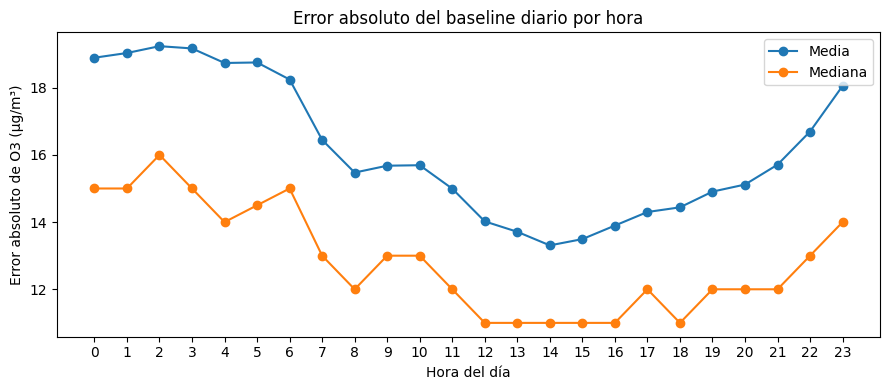

In [50]:
# Visualización del error absoluto de la referencia diaria por hora.
# Esta figura permite identificar franjas horarias donde la regla de persistencia diaria
# resulta menos fiable.

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    baseline_error_by_hour.index,
    baseline_error_by_hour["mean_absolute_residual"],
    marker="o",
    label="Media",
)

ax.plot(
    baseline_error_by_hour.index,
    baseline_error_by_hour["median_absolute_residual"],
    marker="o",
    label="Mediana",
)

ax.set_title("Error absoluto del baseline diario por hora")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Error absoluto de O3 (µg/m³)")
ax.set_xticks(range(24))
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_seasonal_naive_error_by_hour.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [51]:
# Se reconstruye el baseline ingenuo estacional diario sobre el periodo 2020-2024.
# Se excluye 2025 para no usar el test set en decisiones previas al modelado.
baseline_block_df = (
    modeling_eda_df[["timestamp", "o3", "year", "month", "hour", "data_block"]]
    .set_index("timestamp")
    .sort_index()
    .asfreq("h")
    .reset_index()
)

# El baseline lag 24 usa la misma hora del día anterior como predicción.
baseline_block_df["prediction_lag_24"] = baseline_block_df["o3"].shift(24)

baseline_block_df["residual_lag_24"] = (
    baseline_block_df["o3"] - baseline_block_df["prediction_lag_24"]
)

baseline_block_df["abs_residual_lag_24"] = baseline_block_df["residual_lag_24"].abs()

# Se conservan solo las observaciones evaluables.
baseline_block_eval_df = baseline_block_df.dropna(
    subset=["o3", "prediction_lag_24", "residual_lag_24"]
).copy()

baseline_residuals_by_block = (
    baseline_block_eval_df.groupby("data_block", observed=True)
    .agg(
        records=("o3", "size"),
        mae_baseline=("abs_residual_lag_24", "mean"),
        median_abs_error=("abs_residual_lag_24", "median"),
        p90_abs_error=("abs_residual_lag_24", lambda values: values.quantile(0.90)),
        p95_abs_error=("abs_residual_lag_24", lambda values: values.quantile(0.95)),
        residual_mean=("residual_lag_24", "mean"),
        residual_std=("residual_lag_24", "std"),
        rmse_baseline=("residual_lag_24", lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reindex(MODELING_BLOCK_ORDER)
    .reset_index()
)

display(baseline_residuals_by_block.round(2))

baseline_residuals_by_block.to_csv(
    TABLES_DIR / "eda_baseline_lag24_residuals_by_modeling_block.csv",
    index=False,
)

,data_block,records,mae_baseline,median_abs_error,p90_abs_error,p95_abs_error,residual_mean,residual_std,rmse_baseline
0,Entrenamiento (2020-2022),25046,15.99,12.0,35.0,43.0,-0.07,21.07,21.07
1,Calibración (2023),8474,16.18,13.0,36.0,44.0,-0.02,21.20,21.20
2,Validación (2024),8265,16.66,13.0,37.0,45.0,-0.06,21.85,21.85


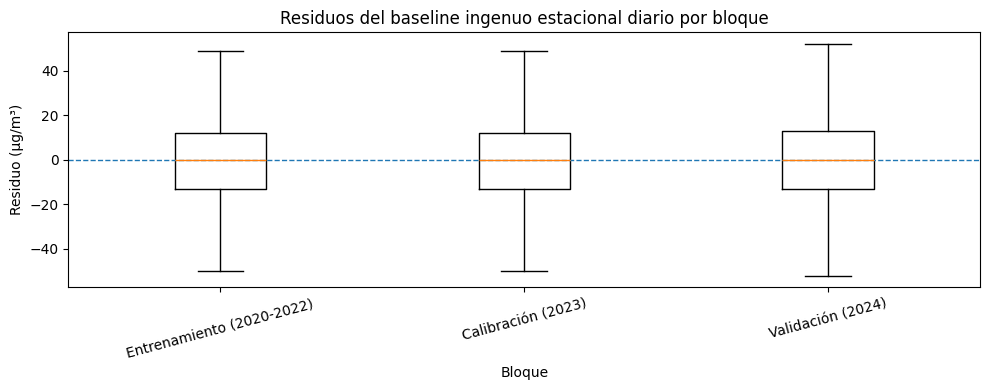

In [52]:
# Se representa la distribución de los residuos del baseline por bloque previo al test.
# Esta figura ayuda a comprobar si la dificultad del baseline cambia entre entrenamiento,
# calibración y validación.
baseline_boxplot_data = [
    baseline_block_eval_df.loc[
        baseline_block_eval_df["data_block"] == block,
        "residual_lag_24",
    ].to_numpy()
    for block in MODELING_BLOCK_ORDER
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(
    baseline_boxplot_data,
    tick_labels=MODELING_BLOCK_ORDER,
    showfliers=False,
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Residuos del baseline ingenuo estacional diario por bloque")
ax.set_xlabel("Bloque")
ax.set_ylabel("Residuo (µg/m³)")
ax.tick_params(axis="x", rotation=15)

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_baseline_lag24_residuals_by_modeling_block.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 7. Comparación interanual y posible singularidad de 2020

Se compara el año 2020 con los posteriores para estudiar posibles diferencias descriptivas asociadas al inicio del periodo disponible. Esta sección no pretende establecer causalidad sobre COVID-19 o ZBE, sino documentar posibles cambios en el comportamiento de la serie temporal.

### 7.1 Objetivo de la comparación interanual

El periodo disponible comienza en 2020, año que coincide con circunstancias potencialmente relevantes para la dinámica meteorológica del Area Metropolitana de Barcelona (AMB), como las restricciones asociadas a la pandemia de COVID-19 y la entrada en vigor de la Zona de Bajas Emisiones (ZBE) en el AMB.

El objetivo de esta sección es, pues, comprobar si el año 2020 se comporta de manera diferente respecto a los demás considerados en la serie temporal. Esta comparación puede ser útil para interpretar las peculiaridades del bloque de entrenamiento (2020-2022) respecto a los de validación y calibración (el de prueba no se considerará, como se ha venido efectuando a lo largo de la EDA).

In [53]:
# Se calcula la media mensual de O3 para cada año.
# Esta vista resume la evolución interanual con menos ruido que la serie diaria.
monthly_profile_by_year = (
    regime_df
    .groupby(["month", "year"])["o3"]
    .mean()
    .unstack("year")
    .reindex(index=range(1, 13), columns=comparison_years)
)

monthly_profile_by_year.index = [MONTH_LABELS[month] for month in range(1, 13)]

display(monthly_profile_by_year.round(2))

monthly_profile_by_year.to_csv(
    TABLES_DIR / "eda_monthly_profile_by_year_2020_2024.csv"
)

year,2020,2021,2022,2023,2024
Ene,19.51,28.77,24.25,27.84,25.23
Feb,27.02,35.79,35.63,35.00,35.34
Mar,53.53,45.88,57.89,51.51,54.15
Abr,63.03,59.86,52.44,56.96,63.31
May,50.30,51.79,46.40,52.67,60.83
Jun,46.44,54.57,49.83,59.05,58.43
Jul,48.93,53.65,55.46,48.61,52.11
Ago,47.92,51.19,61.26,55.49,68.20
Sep,43.34,49.12,48.03,54.99,57.21
Oct,31.59,36.39,34.58,46.69,45.64


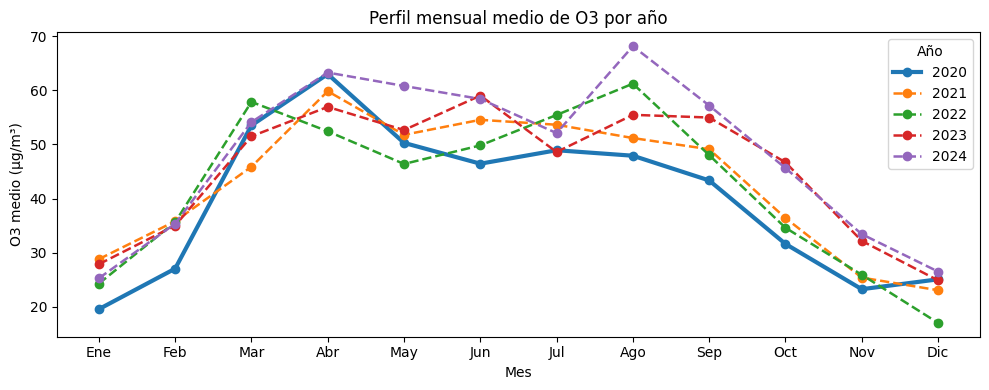

In [54]:
# Perfil mensual superpuesto por año.
# Esta figura ayuda a comprobar si 2020 presenta un nivel o patrón estacional diferente.
fig, ax = plt.subplots(figsize=(10, 4))

for year in comparison_years:
    linewidth = 3 if year == 2020 else 1.8
    linestyle = "-" if year == 2020 else "--"

    ax.plot(
        monthly_profile_by_year.index,
        monthly_profile_by_year[year],
        marker="o",
        linewidth=linewidth,
        linestyle=linestyle,
        label=str(year),
    )

ax.set_title("Perfil mensual medio de O3 por año")
ax.set_xlabel("Mes")
ax.set_ylabel("O3 medio (µg/m³)")
ax.legend(title="Año")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_monthly_profile_by_year_2020_2024.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [55]:
# Se calcula el perfil horario medio de cada año.
# Esta figura permite estudiar si la forma diaria del O3 cambia entre 2020 y los años posteriores.
hourly_profile_by_year = (
    regime_df
    .groupby(["hour", "year"])["o3"]
    .mean()
    .unstack("year")
    .reindex(index=range(24), columns=comparison_years)
)

display(hourly_profile_by_year.round(2))

hourly_profile_by_year.to_csv(
    TABLES_DIR / "eda_hourly_profile_by_year_2020_2024.csv"
)

year,2020,2021,2022,2023,2024
hour,,,,,
0,37.06,40.39,37.26,41.91,45.45
1,36.44,40.14,37.89,42.24,45.87
2,33.60,38.86,36.50,42.52,45.50
3,33.18,38.93,35.03,41.75,43.61
4,32.95,39.84,34.61,40.88,42.56
5,31.44,38.01,32.32,38.14,40.13
6,26.98,32.78,27.82,32.77,35.39
7,20.64,24.34,22.19,27.41,29.24
8,21.15,24.14,22.83,26.31,28.44


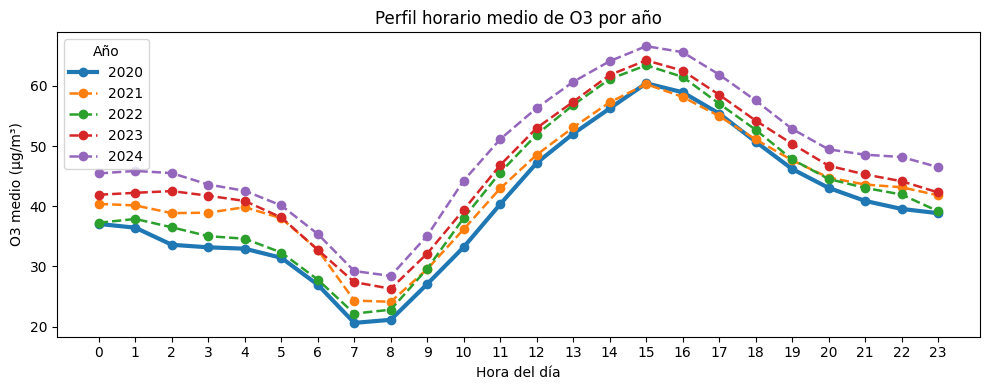

In [56]:
# Perfil horario superpuesto por año.
# Si 2020 presenta una forma diaria distinta, podría indicar un cambio
# en la dinámica de la serie respecto a años posteriores.
fig, ax = plt.subplots(figsize=(10, 4))

for year in comparison_years:
    linewidth = 3 if year == 2020 else 1.8
    linestyle = "-" if year == 2020 else "--"

    ax.plot(
        hourly_profile_by_year.index,
        hourly_profile_by_year[year],
        marker="o",
        linewidth=linewidth,
        linestyle=linestyle,
        label=str(year),
    )

ax.set_title("Perfil horario medio de O3 por año")
ax.set_xlabel("Hora del día")
ax.set_ylabel("O3 medio (µg/m³)")
ax.set_xticks(range(24))
ax.legend(title="Año")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_hourly_profile_by_year_2020_2024.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [57]:
# Se analiza específicamente el periodo marzo-mayo, en el que se tomaron
# medidas restrictivas debido al COVID-19.
spring_df = regime_df[regime_df["month"].isin([3, 4, 5])].copy()

spring_hourly_profile_by_year = (
    spring_df
    .groupby(["hour", "year"])["o3"]
    .mean()
    .unstack("year")
    .reindex(index=range(24), columns=comparison_years)
)

display(spring_hourly_profile_by_year.round(2))

spring_hourly_profile_by_year.to_csv(
    TABLES_DIR / "eda_spring_hourly_profile_by_year_2020_2024.csv"
)

year,2020,2021,2022,2023,2024
hour,,,,,
0,51.91,53.30,47.09,50.01,56.69
1,49.11,50.63,47.45,48.19,56.52
2,44.22,47.40,43.66,48.88,54.26
3,43.67,48.51,41.67,48.05,51.69
4,41.25,47.61,41.61,46.23,50.54
5,39.09,43.61,39.62,43.18,48.88
6,33.90,37.02,34.32,36.28,43.68
7,28.36,26.89,26.39,29.61,35.96
8,30.91,27.69,28.15,30.16,35.87


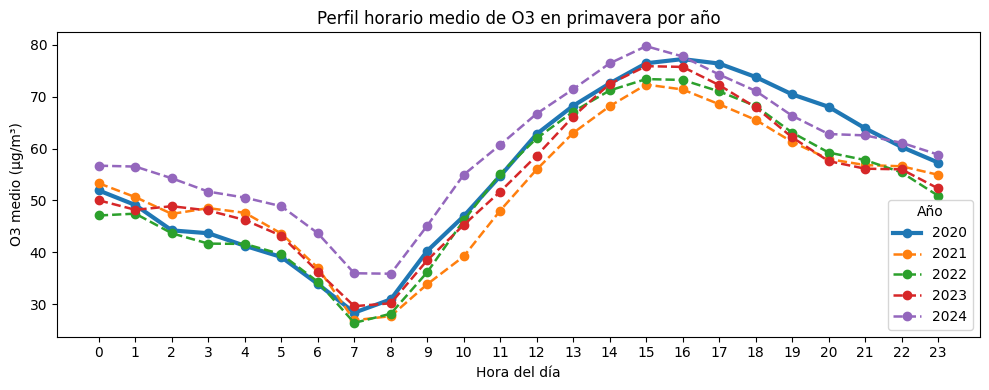

In [58]:
# Perfil horario de primavera por año.
# Esta figura permite revisar si 2020 muestra una forma horaria diferencial en primavera.
fig, ax = plt.subplots(figsize=(10, 4))

for year in comparison_years:
    linewidth = 3 if year == 2020 else 1.8
    linestyle = "-" if year == 2020 else "--"

    ax.plot(
        spring_hourly_profile_by_year.index,
        spring_hourly_profile_by_year[year],
        marker="o",
        linewidth=linewidth,
        linestyle=linestyle,
        label=str(year),
    )

ax.set_title("Perfil horario medio de O3 en primavera por año")
ax.set_xlabel("Hora del día")
ax.set_ylabel("O3 medio (µg/m³)")
ax.set_xticks(range(24))
ax.legend(title="Año")

fig.tight_layout()

fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_spring_hourly_profile_by_year_2020_2024.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [59]:
# Se cuantifica la diferencia entre 2020 y el promedio de 2021-2024.
# Esta tabla resume si el comportamiento de 2020 se separa de los años posteriores
# en diferentes ventanas temporales.
comparison_windows = {
    "todo_el_año": regime_df,
    "primavera_mar_may": regime_df[regime_df["month"].isin([3, 4, 5])],
    "abril": regime_df[regime_df["month"] == 4],
    "verano_jun_aug": regime_df[regime_df["month"].isin([6, 7, 8])],
}

comparison_rows = []

for window_name, window_data in comparison_windows.items():
    data_2020 = window_data[window_data["year"] == 2020]["o3"]
    data_later = window_data[window_data["year"].between(2021, 2024)]["o3"]

    # Se comparan niveles medios y percentiles altos.
    comparison_rows.append(
        {
            "window": window_name,
            "mean_2020": data_2020.mean(),
            "mean_2021_2024": data_later.mean(),
            "mean_difference_2020_minus_later": data_2020.mean() - data_later.mean(),
            "median_2020": data_2020.median(),
            "median_2021_2024": data_later.median(),
            "p90_2020": data_2020.quantile(0.90),
            "p90_2021_2024": data_later.quantile(0.90),
            "p90_difference_2020_minus_later": data_2020.quantile(0.90) - data_later.quantile(0.90),
            "observations_2020": data_2020.count(),
            "observations_2021_2024": data_later.count(),
        }
    )

regime_comparison_summary = pd.DataFrame(comparison_rows)

display(regime_comparison_summary.round(2))

regime_comparison_summary.to_csv(
    TABLES_DIR / "eda_2020_vs_2021_2024_comparison_summary.csv",
    index=False,
)

,window,mean_2020,mean_2021_2024,mean_difference_2020_minus_later,median_2020,median_2021_2024,p90_2020,p90_2021_2024,p90_difference_2020_minus_later,observations_2020,observations_2021_2024
0,todo_el_año,40.11,44.86,-4.75,40.0,47.0,74.0,76.0,-2.0,8667,33894
1,primavera_mar_may,55.51,54.49,1.02,59.0,58.0,86.0,82.0,4.0,2189,8461
2,abril,63.03,58.26,4.77,69.0,63.0,96.0,85.0,11.0,709,2714
3,verano_jun_aug,47.78,55.65,-7.86,48.0,57.0,73.0,82.0,-9.0,2195,8558


## 8. Implicaciones para el modelado y variables candidatas

La EDA se cierra conectando los hallazgos observados con decisiones de modelado, grupos de variables candidatas y la posterior auditoría explicativa.

In [61]:
# Esta tabla resume cómo se traducen los hallazgos de la EDA en decisiones de modelado.
# De esta forma, se trasladan las conclusiones obtenidas a la posterior fase de entrenamiento.
eda_modeling_implications = pd.DataFrame(
    [
        {
            "Hallazgo": "Ciclo horario marcado",
            "Implicación de modelado": "Incluir variables de hora y retardos de corto plazo.",
        },
        {
            "Hallazgo": "Estacionalidad mensual",
            "Implicación de modelado": "Incluir variables de mes o codificación cíclica anual.",
        },
        {
            "Hallazgo": "Diferencias entre días laborables y fines de semana",
            "Implicación de modelado": "Incluir día de la semana como variable predictiva.",
        },
        {
            "Hallazgo": "Autocorrelación alta en retardos cortos",
            "Implicación de modelado": "Considerar lags de, por ejemplo, 1, 2, 3, 6 y 12 horas.",
        },
        {
            "Hallazgo": "Autocorrelación relevante en 24 y 168 horas",
            "Implicación de modelado": (
                "Justificar la referencia estacional diaria basada en lag_24 "
                "y considerar lags diarios/semanales."
            ),
        },
    ]
)

display(
    eda_modeling_implications.style
    .hide(axis="index")
    .set_properties(
        **{
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "top",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("max-width", "520px"),
                ],
            },
        ]
    )
)

eda_modeling_implications.to_csv(
    TABLES_DIR / "eda_modeling_implications.csv",
    index=False,
)

Hallazgo,Implicación de modelado
Ciclo horario marcado,Incluir variables de hora y retardos de corto plazo.
Estacionalidad mensual,Incluir variables de mes o codificación cíclica anual.
Diferencias entre días laborables y fines de semana,Incluir día de la semana como variable predictiva.
Autocorrelación alta en retardos cortos,"Considerar lags de, por ejemplo, 1, 2, 3, 6 y 12 horas."
Autocorrelación relevante en 24 y 168 horas,Justificar la referencia estacional diaria basada en lag_24 y considerar lags diarios/semanales.


### Justificación de variables candidatas a partir de la EDA

Los resultados obtenidos en la EDA permiten justificar la construcción de varios grupos de variables candidatas para la fase de ingeniería de características. La inclusión de estas variables no implica que todas vayan a ser igual de importantes en los modelos finales; su utilidad se evaluará durante el entrenamiento y se auditará posteriormente mediante la técnica de explicabilidad correspondiente a cada familia de modelos.

#### Variables horarias

- **Variables candidatas:** `hour`, `hour_sin`, `hour_cos`.
- **Evidencia EDA:** el perfil horario, el boxplot por hora y el heatmap mes/hora muestran un ciclo diario claro en la concentración de O3.
- **Papel esperado:** capturar la estacionalidad diaria. En los modelos de árboles, la auditoría posterior permitirá comprobar si esta "señal temporal" resulta relevante.

#### Variables mensuales

- **Variables candidatas:** `month`, `month_sin`, `month_cos`.
- **Evidencia EDA:** el perfil mensual, el boxplot mensual y los heatmaps mes/hora muestran diferencias estacionales a lo largo del año.
- **Papel esperado:** capturar la estacionalidad anual y ayudar al modelo a distinguir meses con distintos niveles y variabilidad de O3.

#### Día de la semana

- **Variables candidatas:** `day_of_week`, `is_weekend`.
- **Evidencia EDA:** el perfil semanal y el boxplot por día muestran diferencias entre días laborables y fines de semana.
- **Papel esperado:** capturar potenciales patrones semanales. Su utilidad se comprobará empíricamente durante el entrenamiento.

#### Lags de corto plazo

- **Variables candidatas:** `o3_lag_1`, `o3_lag_2`, `o3_lag_3`, `o3_lag_6`, `o3_lag_12`.
- **Evidencia EDA:** la autocorrelación es elevada en retardos cortos, especialmente durante las primeras horas.
- **Papel esperado:** capturar la inercia inmediata de la serie. Si estos lags resultan importantes, indicará que el modelo aprovecha la memoria reciente del O3.

#### Lags estacionales diarios

- **Variables candidatas:** `o3_lag_24`, `o3_lag_48`, `o3_lag_72`.
- **Evidencia EDA:** la autocorrelación presenta señal relevante en retardos diarios y el baseline `lag_24` resulta competitivo.
- **Papel esperado:** capturar la similitud con la misma hora de los días anteriores.

#### Lag semanal

- **Variable candidata:** `o3_lag_168`.
- **Evidencia EDA:** la autocorrelación en 168 horas sugiere la existencia de una señal semanal, aunque esta no superaría a la diaria.
- **Papel esperado:** aportar la memoria semanal como variable candidata. Su utilidad se validaría durante el entrenamiento.

#### Ventanas móviles de nivel

- **Variables candidatas:** `o3_roll_mean_3`, `o3_roll_mean_6`, `o3_roll_mean_12`, `o3_roll_mean_24`.
- **Evidencia EDA:** la serie muestra inercia temporal y autocorrelación de corto plazo.
- **Papel esperado:** resumir el nivel reciente de O3 sin depender de un único valor pasado.

#### Ventanas móviles de variabilidad

- **Variables candidatas:** `o3_roll_std_6`, `o3_roll_std_12`, `o3_roll_std_24`.
- **Evidencia EDA:** los residuos del baseline y los perfiles de cada bloque de datos muestran que existe una variabilidad no constante.
- **Papel esperado:** capturar la volatilidad reciente y apoyar la estimación de la incertidumbre, especialmente en modelos cuantílicos.